<a href="https://colab.research.google.com/github/luismiguelaristi/MecanismosPythonUPB/blob/main/Motor_Atkinson_2026_redux.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis cinemático de Mecanismo Motor Atkinson

![Atkinson_Gas_Engine_Animated.gif](https://upload.wikimedia.org/wikipedia/commons/5/5a/Atkinson_Gas_Engine_Animated.gif)

Esto es un ejemplo de cuaderno interactivo para reportar el análisis del mecanismo seleccionado para el curso. Aquí debe ir una descripción de su mecanismo, basado en fuentes confiables de información. Debe dejar la referencia bien citada y referenciada al final de la celda.

En este caso, se está analizando un motor basado en el ciclo Atkinson (Wikipedia Contributors, 2025). La imagen fue tomada de Wikipedia Contributors, 2025, desarrollada por Michael Frey, 2016 https://upload.wikimedia.org/wikipedia/commons/5/5a/Atkinson_Gas_Engine_Animated.gif

En este cuaderno vamos a realizar el análisis cinemático de este mecanismo. Aquí va una descripción básica del mecanismo original, y una descripción del mecanismo que hizo en MotionGen.

## Referencias

Wikipedia contributors. (2025, June 18). Atkinson cycle. In Wikipedia, The Free Encyclopedia. Retrieved 21:50, August 4, 2025, from https://en.wikipedia.org/w/index.php?title=Atkinson_cycle&oldid=1296157380

Frey, Michael. (2016). Animation of the Atkinson "Cycle Engine", 1887. Retrieved August 4, 2025, from https://en.wikipedia.org/wiki/Atkinson_cycle#/media/File:Atkinson_Engine_with_Intake.gif



## Diagrama cinemático

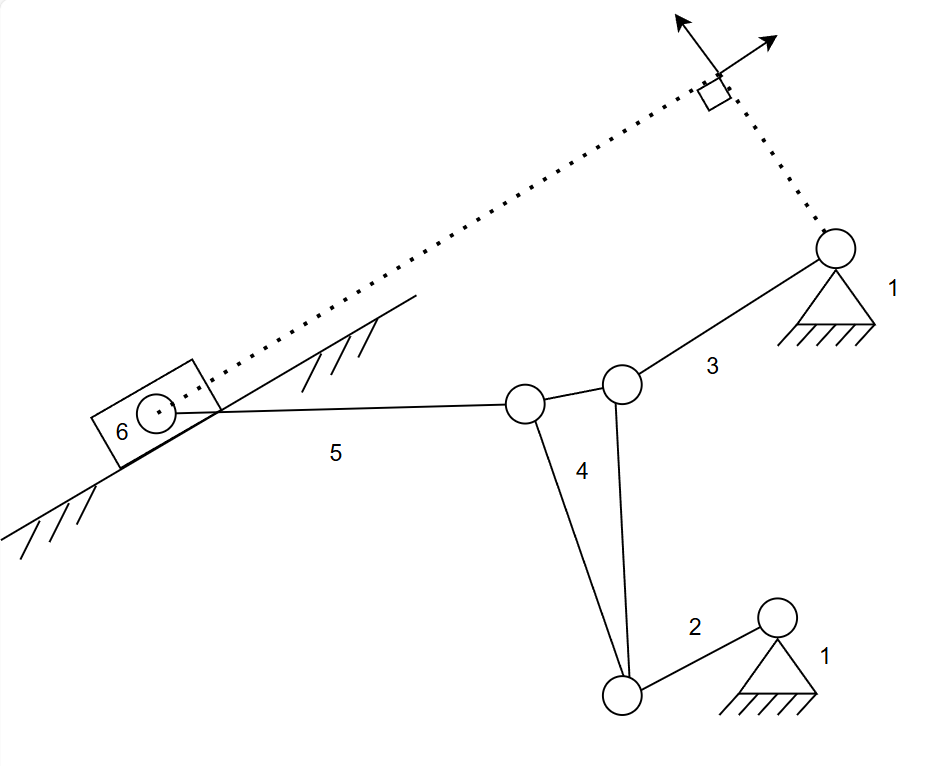

Puedes descargar el diagrama original hecho en draw.io en este enlace: https://drive.google.com/file/d/1sWsnWl9Ki30ONxBoIzbJuWBXuI9IreCc/view?usp=sharing



## Barras, pares, Grados de libertad

Número|Tipo
-|-
1|Chasis
2|Manivela
3|Balancín
4|Acopladora
5|Acopladora
6|Corredera


Tipo par | Cantidad
-|-
Revoluta|6
Prismático|1
Engranaje|0
Leva|0



(usaremos este editor de ecuaciones para generar el código LaTeX de ecuaciones necesario: https://latex.codecogs.com/eqneditor/editor.php)

---



### Grados de Libertad

$F = 3(n-1)-2f_1-f_2$

## Diagrama vectorial
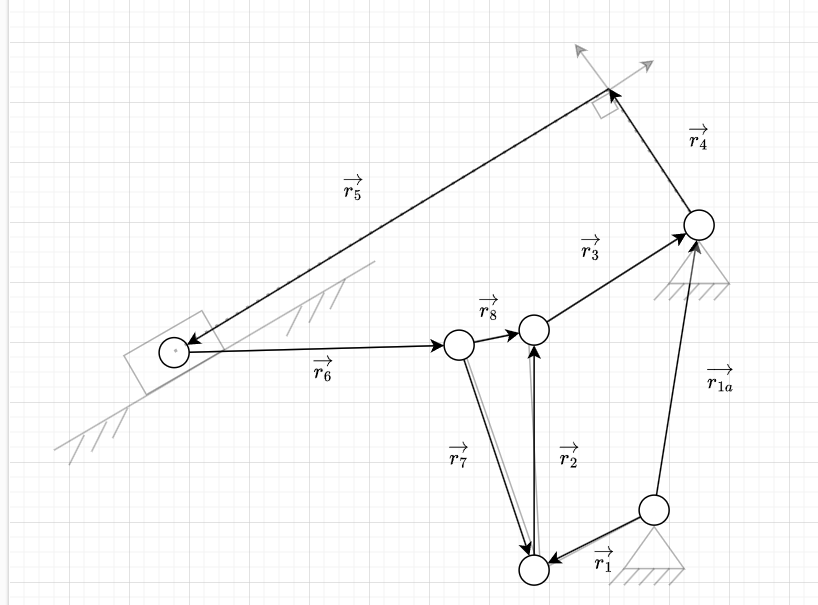


## Tabla de variables y parámetros

Variables Incógnitas: $\theta_2,\theta_3,\theta_6,r_5$

Variable de entrada: $\theta_1$

vector|magnitud (python)|valor[cm]|dirección (python)|valor [°]
-|-|-|-|-
$\overrightarrow{r_{1}}$|r1|27.5 |th1|-110
$\overrightarrow{r_{1a}}$|r1a|55.5 |th1a|80
$\overrightarrow{r_{2}}$|r2|52.5 |th2|91
$\overrightarrow{r_{3}}$|r3|33.5 |th3|55
$\overrightarrow{r_{4}}$|r4|13.5 |th4|119
$\overrightarrow{r_{5}}$|r5|103 |th5|209
$\overrightarrow{r_{6}}$|r6|67.5 |th6|9
$\overrightarrow{r_{8}}$|r8|11 |th8|5

Estas medidas fueron tomadas directamente de la imagen del inicio.

## Ecuaciones de cierre vectorial

$\overrightarrow{r_{2}}+\overrightarrow{r_{3}}-\overrightarrow{r_{1a}}+\overrightarrow{r_{1}}=\overrightarrow{0}$ (1)

$\overrightarrow{r_{4}}+\overrightarrow{r_{5}}+\overrightarrow{r_{6}}+\overrightarrow{r_{8}}+\overrightarrow{r_{3}}=\overrightarrow{0}$ (2)

## Ecuaciones escalares

$r_2\cos(\theta_2) + r_3\cos(\theta_3) + r_{1a}\cos(\theta_{1a}) + r_1\cos(\theta_1) = 0 $ (3)

$r_2\sin(\theta_2) + r_3\sin(\theta_3) + r_{1a}\sin(\theta_{1a}) + r_1\sin(\theta_1) = 0 $ (4)

$r_4\cos(\theta_4) + r_5\cos(\theta_5) + r_{6}\cos(\theta_{6}) + r_8\cos(\theta_8) + r_3\cos(\theta_3) = 0 $ (5)

$r_4\sin(\theta_4) + r_5\sin(\theta_5) + r_{6}\sin(\theta_{6}) + r_8\sin(\theta_8) + r_3\sin(\theta_3) = 0 $ (6)






## Dependencias lineales

Debemos tener mucho cuidado a la hora de identificar variables, podemos notar que $\theta_8$ también es variable, pero esta depende de $\theta_2$:

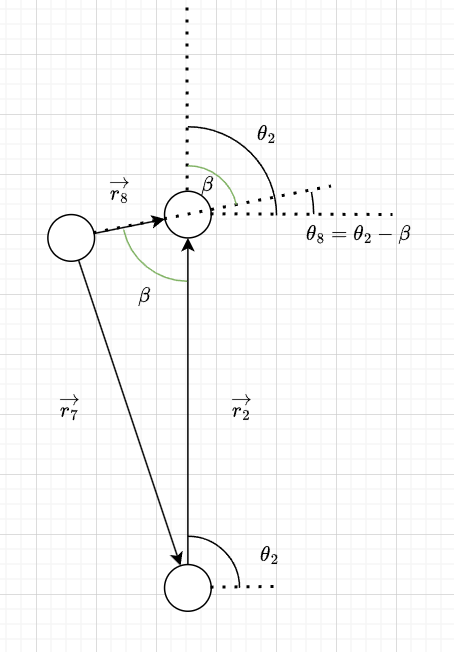

Esta dependencia debe hacerse explícita en la ecuación.

Después de medir el ángulo $\beta$, debo indicar en las ecuaciones escalares que

$\theta_8 = \theta_2 - \beta$


## Solución al sistema de ecuaciones escalares (NO LINEAL) por métodos numéricos

Para resolver este sistema implementaremos un programa en `python`. Debes saber sobre lo siguiente antes de continuar:

Funciones: https://youtu.be/ddHqr-Kh9P0?si=WKh3Ji3Ewo54AcFh

Vectores y matrices con Numpy: https://youtu.be/DHdlPJKXCDc

Ciclos (especialmente ciclo for): https://youtu.be/cPOcABqe6QA



### 0. Definición de parámetros y variables

Definimos parámetros y variables usando variables de python. Como convención, definimos los nombres de las variables (entrada e incógnitas) con el sufijo `_ini` para indicar que estos son solo valores iniciales, ya que cambiarán para cada posición analizada del mecanismo.

In [ ]:
import numpy as np

### TIEMPO DE SIMULACIÓN: esto lo usaré como referencia más adelante
t_sim = 5000 #en milisegundos

r1 = 27.5
r1a = 55.5
th1a = np.radians(80)
r3 = 33.5
r2 = 52.5

r4 = 13.5
th4 = np.radians(119)
th5 = np.radians(209)
r6 = 67.5
r8 = 11
beta = np.radians(84)

#variables
th1_ini = np.radians(-110)  # Entrada
th2_ini = np.radians(91)
th3_ini = np.radians(55)
th6_ini = np.radians(9)
r5_ini = 103
th8_ini = th2_ini-beta # CUIDADO, th8 es linealmente dependiente de th2



### 1. Evaluar las ecuaciones escalares para verificar que SI se cumplan

Vamos a evaluar las ecuaciones en los valores que obtuvimos midiendo sobre el mecanismo. Esta evaluación la realizaremos por medio de una función, ya que luego la necesitaremos para usar el método numérico que resuelve este sistema no lineal.

La función debe recibir, además de las condiciones iniciales, los valores de las variables de entrada empacados en una lista.

La función es tal que:

- reciba como argumento una lista con las condiciones iniciales de las incógnitas, i.e., valores estimados Y una lista con valores de las variables de entrada
- debe evaluar las ecuaciones Y retornar el valor resultante de la evaluación
- los parámetros serán tomados del entorno global (variables de la sesión de Colab)

In [ ]:

# definición de función atkinson()
# recibe valores aproximados de las incógnitas a una solución (x0)
# NO LAS VARIABLES DE ENTRADA
# entrega LA EVALUACIÓN DE LAS ECUACIONES en los valores que le di, osea x0
def atkinson(x0,entradas):
  th2 = x0[0]
  th3 = x0[1]
  th6 = x0[2]
  r5 = x0[3]
  th8 = th2 - beta
  th1 = entradas[0]
  x1 = -r1*np.cos(th1)+r1a*np.cos(th1a)-r3*np.cos(th3)-r2*np.cos(th2)
  y1 = -r1*np.sin(th1)+r1a*np.sin(th1a)-r3*np.sin(th3)-r2*np.sin(th2)
  x2 = r4*np.cos(th4) + r5*np.cos(th5) + r6*np.cos(th6) + r8*np.cos(th8) + r3*np.cos(th3)
  y2 = r4*np.sin(th4) + r5*np.sin(th5) + r6*np.sin(th6) + r8*np.sin(th8) + r3*np.sin(th3)
  return x1,y1,x2,y2


x0 = [th2_ini,th3_ini,th6_ini,r5_ini]
entradas = [th1_ini]
x1,y1,x2,y2 = atkinson(x0,entradas)

print("evaluación de la primera ecuación escalar = ",x1)
print("evaluación de la segunda ecuación escalar = ",y1)
print("evaluación de la primera ecuación escalar = ",x2)
print("evaluación de la segunda ecuación escalar = ",y2)

evaluación de la primera ecuación escalar =  0.7444685221678627
evaluación de la segunda ecuación escalar =  0.5647798843982628
evaluación de la primera ecuación escalar =  0.17102156730308238
evaluación de la segunda ecuación escalar =  1.2134578123625666


implementé las ecuaciones escalares, y al evaluarlas con los valores medidos obtuve valores cercanos a cero. IDEALMENTE debería dar cero, si mide con herramientas más precisas debería ocurrir esto.


## Solución del sistema de ecuaciones usando `fsolve()`




In [ ]:
from scipy.optimize import fsolve

th1 = th1_ini
[th2,th3,th6,r5],info,exitflag,msg = fsolve(atkinson,x0,full_output=True,args=entradas)

print("th1 = ",np.degrees(th1))
print("th2 = ",np.degrees(th2))
print("th3 = ",np.degrees(th3))
print("th6 = ",np.degrees(th6))
print("r5 = ",r5)
print("exitflag = ",exitflag) #esto debe ser 1, si es diferente es que hay problemas de convergencia
print(msg)

th1 =  -110.0
th2 =  89.28492067582351
th3 =  56.709095875057876
th6 =  7.5784299744393095
r5 =  102.56632950161342
exitflag =  1
The solution converged.


## Gráfica de mecanismo en el plano

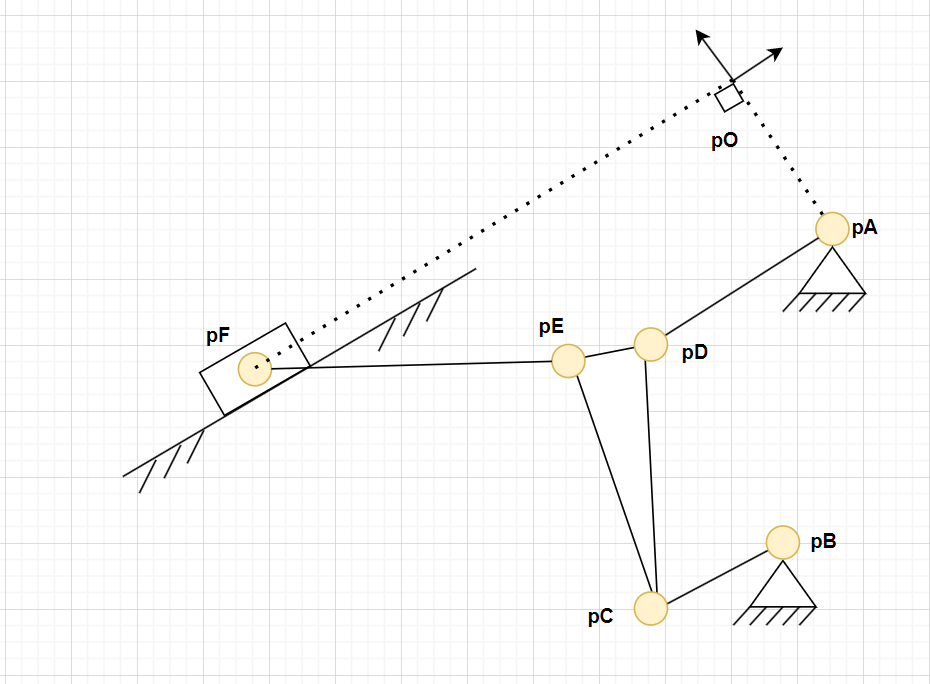



Vamos a ubicar estos puntos en el plano para poder graficarlos. Para esto usaremos los vectores que ya conocemos:
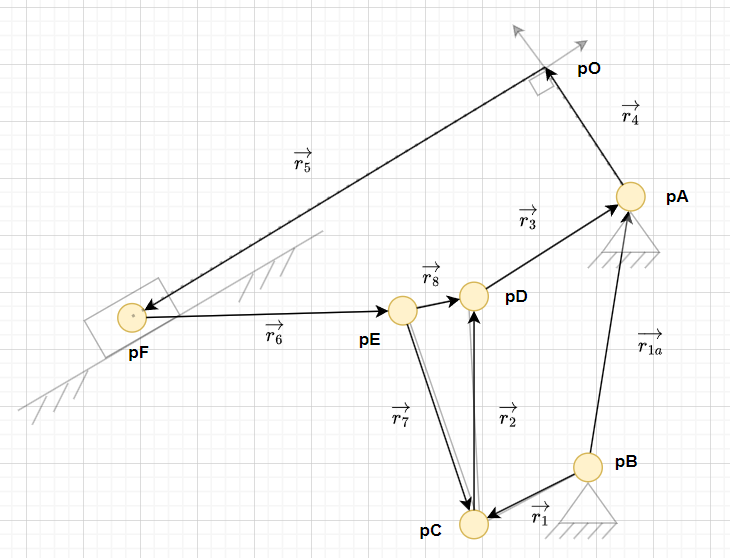

### Cálculo de la posición inicial de los puntos

Esto me servirá para visualizar la primera posición, así vemos si lo que llevamos tiene sentido.

In [ ]:


pOx = 0
pOy = 0
pAx = -r4*np.cos(th4)
pAy = -r4*np.sin(th4)
pDx = pAx - r3*np.cos(th3)
pDy = pAy - r3*np.sin(th3)
pCx = pDx - r2*np.cos(th2)
pCy = pDy - r2*np.sin(th2)
pBx = pCx - r1*np.cos(th1)
pBy = pCy - r1*np.sin(th1)
pEx = pDx - r8*np.cos(th2-beta)
pEy = pDy - r8*np.sin(th2-beta)
pFx = pEx - r6*np.cos(th6)
pFy = pEy - r6*np.sin(th6)

Ahora para graficar, usamos Matplotlib.

(-120.0, 40.0)

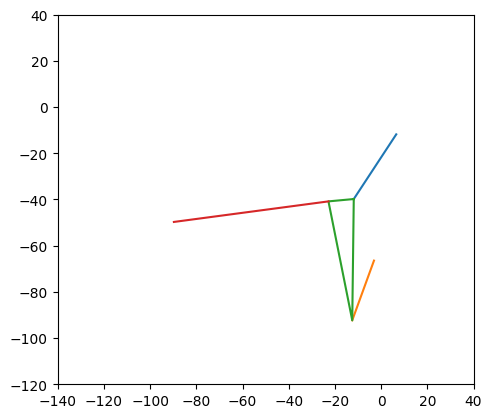

In [ ]:
import matplotlib.pyplot as plt

# Creo una FIGURA y un grupo de ejes (AXES), ya que los usaré después en la animación
fig_anim,ax_anim = plt.subplots()

hr3 = plt.plot([pDx,pAx],[pDy,pAy])
hr1 = plt.plot([pBx,pCx],[pBy,pCy])
# para hacer una barra compuesta por varias aristas, delimito los puntos
hDCED = plt.plot([pDx,pCx,pEx,pDx],[pDy,pCy,pEy,pDy])
hr6 = plt.plot([pEx,pFx],[pEy,pFy])

plt.axis("scaled")
plt.xlim([-140,40])
plt.ylim([-120,40])

Si la figura graficada tiene sentido y se parece al mecanismo real en la posición medida, podemos continuar.

Si todo salió bien, obtenemos valores para las incógnitas, y en las demás variables hay información sobre cómo fue el proceso, si fue exitoso o no y posibles fallos.

## Hallar el rango de movimiento del mecanismo

Ahora, hay que iterar para n variables de entrada. En el caso del ejemplo, es 1 variable de entrada, por lo que hay que describir 1 incremento y 1 límite de iteración. Cuando tenemos 2 o más variables de entrada, aparecen infinitas combinaciones de valores, por lo que podemos tomar varios caminos para explorar las posibles soluciones.

Mi función quedaría así:

In [ ]:
def atkinson_1gdl(entradas_ini,incrementos,limites):
  # definir el valor inicial de las variables de entrada
  th1 = entradas_ini[0]
  # definir el tamaño del incremento para empezar a mover el mecanismo (por ejemplo, un grado si es una manivela)
  # incremento = np.radians(1)
  incremento_th1 = incrementos[0]
  # definir el límite de búsqueda (por ejemplo, si la variable de entrada es un ángulo, no tiene sentido buscar más de 360º).
  # limite_sup = th2_ini + np.radians(360)
  limite_sup_th1 = limites[0]
  # Las condiciones iniciales no cambian
  # definir condiciones iniciales (x0) (valores aproximados de las incógnitas)
  x0 = [th2_ini,th3_ini,th6_ini,r5_ini]
  ### HAY QUE actualizar los valores iniciales de las variables de entrada
  entradas = [th1_ini]
  # crear listas de numpy vacías para almacenar los valores de las variables hallados
  _th2v = np.empty(0)
  _th3v = np.empty(0)
  _th6v = np.empty(0)
  _r5v = np.empty(0)

  _th1v = np.empty(0)

  ### El solucionador en esencia sigue haciendo lo mismo... PERO
  # crear bandera solucion_ok, inicializar en 1 (es lo que arroja fsolve cuando está todo bien).
  solucion_ok = 1
  # MIENTRAS que solucion_ok = 1:
  while solucion_ok == 1:
    # resolver con fsolve, usando la salida completa (ver ejemplo):
    [th2,th3,th6,r5],info,solucion_ok,mensaje = fsolve(atkinson,
                                                x0,
                                                full_output=True,
                                                args=entradas)
    ### AHORA hay que revisar todas las variables de entrada
    # SI solucion_ok diferente de 1 O variables de entrada mayor a límites:
    if solucion_ok != 1 or th1 > limite_sup_th1:
      # Imprimir mensajes de cómo quedaron las cosas
      print(solucion_ok)
      print(mensaje)
      print("último valor de th2:",th2)
      print("último valor de th3:",th3)
      print("último valor de th6:",th6)
      print("último valor de r5:",r5)
      print("ciclos:",len(_th1v))
      # romper ciclo (break)
      break
    else:
      # guardar valores de incógnitas en listas
      _th2v = np.append(_th2v,th2)
      _th3v = np.append(_th3v,th3)
      _th6v = np.append(_th6v,th6)
      _r5v = np.append(_r5v,r5)
      # también guardar valores de variables de entrada en listas
      _th1v = np.append(_th1v,th1)

      # POR ÚLTIMO aumentar variables de entrada en incremento
      th1 = th1 + incremento_th1
      # actualizar condiciones iniciales
      x0 = [th2,th3,th6,r5]
      entradas = [th1]
  ## RETORNAR las listas con todos los valores obtenidos, tanto incógnitas como variables de entrada.
  return _th2v,_th3v,_th6v,_r5v,_th1v


## Solución del análisis de posición para un rango de movimiento, 1GDL

In [ ]:
th2v,th3v,th6v,r5v,th1v = atkinson_1gdl([th1_ini], # valores iniciales de th1
                                    [np.radians(1)],  # incrementos de th1
                                    [th1_ini + np.radians(360)]) # límites absolutos de th1


1
The solution converged.
último valor de th2: 1.5623066304148585
último valor de th3: 0.9984110972150803
último valor de th6: 0.12755032424075746
último valor de r5: 102.33102941490533
ciclos: 361


### Gráficas de incógnitas vs variable de entrada

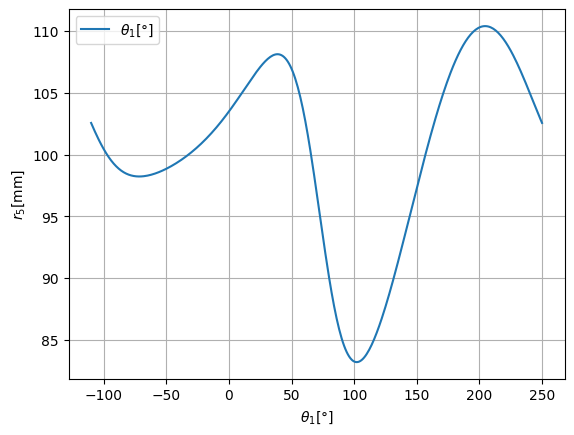

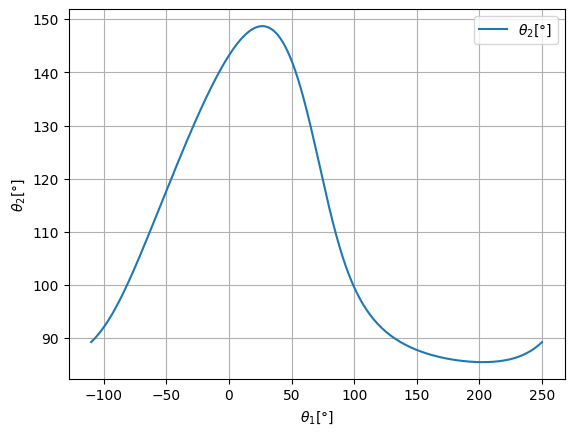

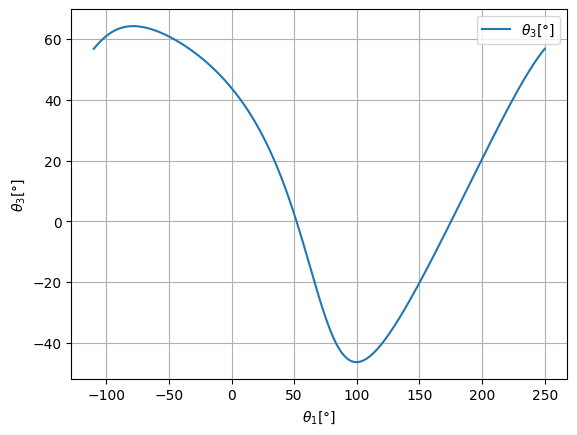

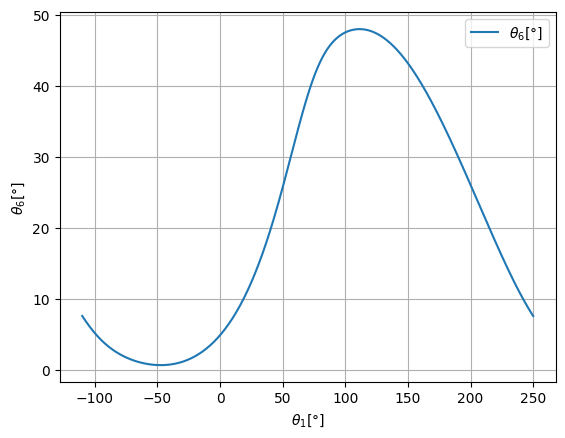

In [ ]:
# %matplotlib inline
plt.figure()
plt.plot(np.degrees(th1v),r5v)
plt.legend([r"$\theta_1[°]$"])
plt.ylabel(r"$r_5$[mm]")
plt.xlabel(r"$\theta_1$[°]")
plt.grid()

plt.figure()
plt.plot(np.degrees(th1v),np.degrees(th2v))
plt.legend([r"$\theta_2[°]$"])
plt.xlabel(r"$\theta_1$[°]")
plt.ylabel(r"$\theta_2$[°]")
plt.grid()

plt.figure()
plt.plot(np.degrees(th1v),np.degrees(th3v))
plt.legend([r"$\theta_3[°]$"])
plt.xlabel(r"$\theta_1$[°]")
plt.ylabel(r"$\theta_3$[°]")
plt.grid()

plt.figure()
plt.plot(np.degrees(th1v),np.degrees(th6v))
plt.legend([r"$\theta_6[°]$"])
plt.xlabel(r"$\theta_1$[°]")
plt.ylabel(r"$\theta_6$[°]")
plt.grid()

Opcional: es posible hacer gráficos interactivos en Google Colab con el módulo `plotly`, para esto ver el siguiente ejemplo:

https://colab.research.google.com/drive/1uVAuE_s6-tqM4E1B4aCiO1NtHyQgyF_m?usp=sharing

## Consolidación de datos con Pandas

In [ ]:
import pandas as pd

df = pd.DataFrame({'th1':th1v,
                   'th2':th2v,
                   'th3': th3v,
                   'th6': th6v,
                   'r5': r5v
                   })

df

,th1,th2,th3,th6,r5
0,-1.919862,1.558316,0.989760,0.132269,102.566330
1,-1.902409,1.562307,0.998411,0.127550,102.331029
2,-1.884956,1.566475,1.006781,0.122944,102.100064
3,-1.867502,1.570823,1.014865,0.118451,101.873888
4,-1.850049,1.575356,1.022655,0.114072,101.652933
...,...,...,...,...,...
356,4.293510,1.544038,0.952504,0.152225,103.541215
357,4.310963,1.547364,0.962200,0.147078,103.293440
358,4.328417,1.550849,0.971647,0.142034,103.048029
359,4.345870,1.554498,0.980837,0.137097,102.805492


## Animación

Para hacer la animación, debemos encontrar la posición de todos los puntos que conforman el mecanismo ($O,A,B,C,D,E,F$) PARA CADA POSICIÓN DE LA BARRA DE ENTRADA A ANALIZAR

Cabe resaltar que los puntos $O,A,B$ son fijos, por lo que solo tienen una posición, de manera que son cantidades escalares. Los demás se convertiran en cantidades vectoriales, para lo cual las agregaremos al DataFrame.

También calcularemos la trayectoria de nuestro punto de interés, que en este caso es el mismo punto $F$, por lo que no hay que agregarlo como adicional.

NOTA: lo haremos con una función ya que nos facilitará hacer análisis con más de 1 GDL.


In [ ]:
def calcularPuntos(df):
  df['Dx'] = pAx - r3*np.cos(df['th3'])
  df['Dy'] = pAy - r3*np.sin(df['th3'])
  df['Cx'] = df['Dx'] - r2*np.cos(df['th2'])
  df['Cy'] = df['Dy'] - r2*np.sin(df['th2'])
  df['Ex'] = df['Dx'] - r8*np.cos(df['th2']-beta)
  df['Ey'] = df['Dy'] - r8*np.sin(df['th2']-beta)
  df['Fx'] = df['Ex'] - r6*np.cos(df['th6'])
  df['Fy'] = df['Ey'] - r6*np.sin(df['th6'])
  return df

df = calcularPuntos(df)


verificamos que el DataFrame tenga la nueva información de los puntos.

In [ ]:
df

,th1,th2,th3,th6,r5,Dx,Dy,Cx,Cy,Ex,Ey,Fx,Fy
0,-1.919862,1.558316,0.989760,0.132269,102.566330,-11.842889,-39.809832,-12.498098,-92.305743,-22.796128,-40.823026,-89.706533,-49.725143
1,-1.902409,1.562307,0.998411,0.127550,102.331029,-11.599965,-39.967849,-12.045668,-92.465957,-22.549073,-41.024747,-89.500735,-49.611068
2,-1.884956,1.566475,1.006781,0.122944,102.100064,-11.363617,-40.118741,-11.590511,-92.618251,-22.308225,-41.221264,-89.298728,-49.499093
3,-1.867502,1.570823,1.014865,0.118451,101.873888,-11.134181,-40.262577,-11.132766,-92.762577,-22.073891,-41.412685,-89.100910,-49.389441
4,-1.850049,1.575356,1.022655,0.114072,101.652933,-10.911971,-40.399439,-10.672571,-92.898893,-21.846355,-41.599125,-88.907659,-49.282320
...,...,...,...,...,...,...,...,...,...,...,...,...,...
356,4.293510,1.544038,0.952504,0.152225,103.541215,-12.873165,-39.105490,-14.277802,-91.586696,-23.839753,-39.962199,-90.559187,-50.197777
357,4.310963,1.547364,0.962200,0.147078,103.293440,-12.607559,-39.292492,-13.837650,-91.778080,-23.571237,-40.185668,-90.342478,-50.077653
358,4.328417,1.550849,0.971647,0.142034,103.048029,-12.347056,-39.472197,-13.394225,-91.961752,-23.307555,-40.403576,-90.127837,-49.958676
359,4.345870,1.554498,0.980837,0.137097,102.805492,-12.092041,-39.644631,-12.947663,-92.137658,-23.049068,-40.616000,-89.915709,-49.841092


### Visualización de trayectoria

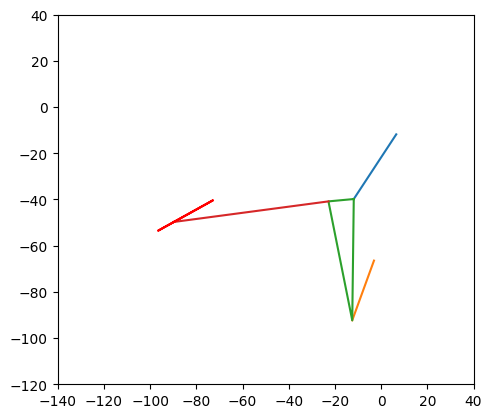

In [ ]:
ax_anim.plot(df["Fx"],df["Fy"],'r')
fig_anim

### Módulo FuncAnimation



Debemos importar el módulo de animaciones

In [ ]:
from matplotlib.animation import FuncAnimation

### Función de animación

Definimos la función que dibuja cada cuadro (plot)

In [ ]:
def animar(pos):
    #tomar el punto actual del dataframe
    #El módulo de animación tomará una posición a la vez y graficará con esto
    current_Dx = df['Dx'].loc[pos]
    current_Dy = df['Dy'].loc[pos]
    current_Cx = df['Cx'].loc[pos]
    current_Cy = df['Cy'].loc[pos]
    current_Ex = df['Ex'].loc[pos]
    current_Ey = df['Ey'].loc[pos]
    current_Fx = df['Fx'].loc[pos]
    current_Fy = df['Fy'].loc[pos]
    #modificar la posición de las barras previamente creadas en la gráfica (fig)
    hr3[0].set_xdata([current_Dx,pAx]) #barra 3
    hr3[0].set_ydata([current_Dy,pAy]) #barra 3
    hr1[0].set_xdata([pBx,current_Cx]) #barra 1
    hr1[0].set_ydata([pBy,current_Cy]) #barra 1
    hDCED[0].set_xdata([current_Dx,current_Cx,current_Ex,current_Dx]) #barra ternaria
    hDCED[0].set_ydata([current_Dy,current_Cy,current_Ey,current_Dy])
    hr6[0].set_xdata([current_Ex,current_Fx]) #acopladora
    hr6[0].set_ydata([current_Ey,current_Fy])
    # Retornar siempre las barras que se están moviendo.
    return hr3[0],hr1[0],hDCED[0],hr6[0]

### Configuración y ejecución de animación

Debemos especificar:

- longitud del video en milisegundos
- número máximo de cuadros (si especificamos muchos, el video quedará muy pesado)

Luego ejecutar la animación con la función FuncAnimation()

In [ ]:
def generar_animacion(fig,videoLength):
  fps = 24
  maxFrames = int(np.ceil(videoLength*fps/1000))
  numpos = len(df)

  increment = int(np.ceil(numpos/maxFrames))
  totalFrames = range(0,numpos,increment)
  print("Número de Cuadros:",len(totalFrames))
  print("Incremento de la variable de entrada:",increment)
  animacion = FuncAnimation(fig,
                            animar,
                            frames = totalFrames,
                            interval=videoLength/(len(totalFrames)),
                            blit=True)
  return animacion

### AQUÍ USO EL TIEMPO DE SIMULACIÓN
animacion = generar_animacion(fig_anim,t_sim)

Número de Cuadros: 91
Incremento de la variable de entrada: 4


### Presentación de animación

In [ ]:
#En Jupyter se pueden mostrar las animaciones directamente en el cuaderno
from IPython.display import HTML

# Comentar para reducir tamaño del cuaderno, generar animación en formato gif o mp4, requiere instalar ffmpeg
#animacion.save('animation.mp4', writer='ffmpeg', fps=15)
HTML(animacion.to_jshtml())

## Análisis de velocidad

para calcular la velocidad lineal instantánea de cualquier punto del mecanismo, usaremos las ecuaciones de velocidad (4):

$\overrightarrow{V_B} = \overrightarrow{V_A}+\overrightarrow{\omega}\times \overrightarrow{r_{AB}}$, (4)

donde

$\overrightarrow{\omega} = \begin{bmatrix}
0 & 0 & \dot{\theta}
\end{bmatrix}$ (5)

Apliquémoslo al caso de estudio

### Definición de puntos

Recordemos la definición de puntos que usamos para la animación

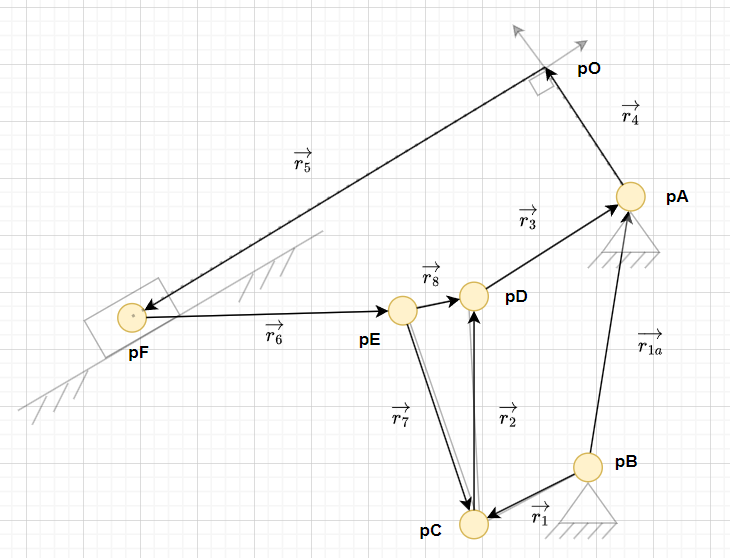

## Aplicándolo al caso de estudio

Vamos a hallar la velocidad de cualquier punto del mecanismo estudiado, en este caso, propongámonos encontrar la velocidad del punto $pF$

$\overrightarrow{V_{pF}} = \overrightarrow{V_{pE}}+\overrightarrow{\omega_6}\times \overrightarrow{r_6\prime}$,

donde $\overrightarrow{r_6\prime}$ es el mismo vector $\overrightarrow{r_6}$ con dirección contraria, y  $\overrightarrow{\omega_6} = \begin{bmatrix}
0 & 0 & \dot{\theta_6}
\end{bmatrix}$

Para esto, debemos conocer la velocidad del punto $pE$, $pD$, además de hallar $\dot \theta_6$, y las demás variables de posición derivadas con respecto al tiempo.

*¿Por qué debemos hacer esto?*

*¿Cómo obtenemos esas velocidades?*

Derivando el modelo de posición con respecto al tiempo.

### Derivando el modelo de posición con respecto al tiempo

recordemos que las siguientes ecuaciones modelan la posición de este mecanismo:

> $-r_2\cos(\theta_2) - r_3\cos(\theta_3) + r_{1a}\cos(\theta_{1a}) - r_1\cos(\theta_1) = 0 $ (3)

>$-r_2\sin(\theta_2) - r_3\sin(\theta_3) + r_{1a}\sin(\theta_{1a}) - r_1\sin(\theta_1) = 0 $ (4)

>$r_4\cos(\theta_4) + r_5\cos(\theta_5) + r_{6}\cos(\theta_{6}) + r_8\cos(\theta_8) + r_3\cos(\theta_3) = 0 $ (5)

>$r_4\sin(\theta_4) + r_5\sin(\theta_5) + r_{6}\sin(\theta_{6}) + r_8\sin(\theta_8) + r_3\sin(\theta_3) = 0 $ (6)

¿Cómo derivamos estas ecuaciones con respecto al tiempo?

Recordemos también la lista de variables:

> Variables Incógnitas: $\theta_2,\theta_3,\theta_6,r_5$

> Variable de entrada: $\theta_1$

#### Cuidado con las dependencias lineales

¿Recuerdan que hay variables que dependen linealmente de otras? en este caso específico, la variable $\theta_8$ es dependiente de $\theta_2$, y vimos que la dependencia se expresaba como

$\theta_8 = \theta_2 - \beta$

Es conveniente dejar el modelo de posición expresado netamente en términos de las variables LI, de manera que las últimas ecuaciones quedan así:

>$r_4\cos(\theta_4) + r_5\cos(\theta_5) + r_{6}\cos(\theta_{6}) + r_8\cos(\theta_2 - \beta) + r_3\cos(\theta_3) = 0 $ (7)

>$r_4\sin(\theta_4) + r_5\sin(\theta_5) + r_{6}\sin(\theta_{6}) + r_8\sin(\theta_2 - \beta) + r_3\sin(\theta_3) = 0 $ (8)


Teniendo esto en cuenta, las derivadas con respecto al tiempo de las ecuaciones anteriores sería

$r_{1} \sin{\left(\theta_{1} \right)} \dot{\theta}_{1} + r_{2} \sin{\left(\theta_{2} \right)} \dot{\theta}_{2} + r_{3} \sin{\left(\theta_{3} \right)} \dot{\theta}_{3} = 0$ (9)

$- r_{1} \cos{\left(\theta_{1} \right)} \dot{\theta}_{1} - r_{2} \cos{\left(\theta_{2} \right)} \dot{\theta}_{2} - r_{3} \cos{\left(\theta_{3} \right)} \dot{\theta}_{3} = 0$ (10)

$- r_{3} \sin{\left(\theta_{3} \right)} \dot{\theta}_{3} - r_{6} \sin{\left(\theta_{6} \right)} \dot{\theta}_{6} + r_{8} \sin{\left(\beta - \theta_{2} \right)} \dot{\theta}_{2} + \cos{\left(\theta_{5} \right)} \dot{r}_{5} = 0$ (11)

$r_{3} \cos{\left(\theta_{3} \right)} \dot{\theta}_{3} + r_{6} \cos{\left(\theta_{6} \right)} \dot{\theta}_{6} + r_{8} \cos{\left(\beta - \theta_{2} \right)} \dot{\theta}_{2} + \sin{\left(\theta_{5} \right)} \dot{r}_{5} = 0$ (12)




### Solución del sistema de ecuaciones

Este sistema de ecuaciones es LINEAL, por lo que podemos usar álgebra lineal para resolverlo. Para esto lo llevamos a la forma $Ax=b$ (estudie esto si es necesario).

$A = \left[\begin{smallmatrix}r_{2} \sin{\left(\theta_{2} \right)} & r_{3} \sin{\left(\theta_{3} \right)} & 0 & 0\\- r_{2} \cos{\left(\theta_{2} \right)} & - r_{3} \cos{\left(\theta_{3} \right)} & 0 & 0\\r_{8} \sin{\left(\beta - \theta_{2} \right)} & - r_{3} \sin{\left(\theta_{3} \right)} & - r_{6} \sin{\left(\theta_{6} \right)} & \cos{\left(\theta_{5} \right)}\\r_{8} \cos{\left(\beta - \theta_{2} \right)} & r_{3} \cos{\left(\theta_{3} \right)} & r_{6} \cos{\left(\theta_{6} \right)} & \sin{\left(\theta_{5} \right)}\end{smallmatrix}\right]$ (13)


$b = \left[\begin{smallmatrix}- r_{1} \sin{\left(\theta_{1} \right)} \dot{\theta}_{1}\\r_{1} \cos{\left(\theta_{1} \right)} \dot{\theta}_{1}\\0\\0\end{smallmatrix}\right]$ (14)

para resolver el sistema, aplicamos

$x = A^-b$ (15)

que en python se implementa usando la función `np.linalg.solve(A,b)`

Antes de resolver el sistema, debemos aclarar algo sobre las variables de entrada y sus derivadas con respecto al tiempo.




## Tiempo

Como estamos hablando de velocidad, el tiempo se convierte en un elemento fundamental. Debemos definir un vector de tiempo que nos permitirá evaluar el comportamiento del mecanismo, tanto en posición como en velocidad y aceleración.

### Definición

Podríamos usar un criterio arbitrario para definir el rango de tiempo y la unidad mínima a la que transcurre en la simulación, pero en este caso, para ser consistentes con la animación, usaremos el tiempo de simulación (`t_sim`) y el número de elementos calculados en el análisis de posición (calculando el tamaño del DataFrame con `len()`)

In [ ]:
t_final = t_sim/1000 # divido por 1000 para que el tiempo de animación quede en segundos.
muestras = len(df)
df["t"] = np.linspace(0,t_final,muestras)
df = df.set_index("t")
df

,th1,th2,th3,th6,r5,Dx,Dy,Cx,Cy,Ex,Ey,Fx,Fy
t,,,,,,,,,,,,,
0.000000,-1.919862,1.558316,0.989760,0.132269,102.566330,-11.842889,-39.809832,-12.498098,-92.305743,-22.796128,-40.823026,-89.706533,-49.725143
0.013889,-1.902409,1.562307,0.998411,0.127550,102.331029,-11.599965,-39.967849,-12.045668,-92.465957,-22.549073,-41.024747,-89.500735,-49.611068
0.027778,-1.884956,1.566475,1.006781,0.122944,102.100064,-11.363617,-40.118741,-11.590511,-92.618251,-22.308225,-41.221264,-89.298728,-49.499093
0.041667,-1.867502,1.570823,1.014865,0.118451,101.873888,-11.134181,-40.262577,-11.132766,-92.762577,-22.073891,-41.412685,-89.100910,-49.389441
0.055556,-1.850049,1.575356,1.022655,0.114072,101.652933,-10.911971,-40.399439,-10.672571,-92.898893,-21.846355,-41.599125,-88.907659,-49.282320
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4.944444,4.293510,1.544038,0.952504,0.152225,103.541215,-12.873165,-39.105490,-14.277802,-91.586696,-23.839753,-39.962199,-90.559187,-50.197777
4.958333,4.310963,1.547364,0.962200,0.147078,103.293440,-12.607559,-39.292492,-13.837650,-91.778080,-23.571237,-40.185668,-90.342478,-50.077653
4.972222,4.328417,1.550849,0.971647,0.142034,103.048029,-12.347056,-39.472197,-13.394225,-91.961752,-23.307555,-40.403576,-90.127837,-49.958676


In [ ]:
t_muestreo = df.index[1]-df.index[0]
t_muestreo

np.float64(0.013888888888888888)

### Variable de entrada

En este caso, la variable de entrada es $\theta_1$, por lo cual debemos dar valores a $\dot{\theta_1}$. Vamos a calcular la derivada de mi variable de entrada usando derivación numérica `np.gradient()`

In [ ]:
df['th1p'] = np.gradient(df['th1'],df.index)
df['th1p']

,th1p
t,
0.000000,1.256637
0.013889,1.256637
0.027778,1.256637
0.041667,1.256637
0.055556,1.256637
...,...
4.944444,1.256637
4.958333,1.256637
4.972222,1.256637


Es evidente que el valor es constante, ya que definimos nuestra variable de entrada con cambios constantes. Para simplificar en este caso, vamos a definir un valor constante para $\dot{\theta_1}$

In [ ]:
th1p = df['th1p'][0]
th1p #rad/s

np.float64(1.256637061435919)

### Solución Analítica (ingresando matrices a mano)



In [ ]:
th2pv = np.zeros(0) #th2pv = []
th3pv = np.zeros(0)
th6pv = np.zeros(0)
r5pv = np.zeros(0)
for th2,th3,th6,r5,th1 in zip(df['th2'],df['th3'],df['th6'],df['r5'],df['th1']):
    # velocidad
    am = [[r2*np.sin(th2),r3*np.sin(th3),0,0],
          [-r2*np.cos(th2),-r3*np.cos(th3),0,0],
          [r8*np.sin(beta-th2),-r3*np.sin(th3),-r6*np.sin(th6),np.cos(th5)],
          [r8*np.cos(beta-th2),r3*np.cos(th3),r6*np.cos(th6),np.sin(th5)]]
    bv = [-r1*np.sin(th1)*th1p,
         r1*np.cos(th1)*th1p,
          0,
          0]
    [th2p,th3p,th6p,r5p] = np.linalg.solve(am,bv) # el resultado de solve es el vector x
    # print(th2p,th3p,th6p,r5p)
    th2pv = np.append(th2pv,th2p)
    th3pv = np.append(th3pv,th3p)
    th6pv = np.append(th6pv,th6p)
    r5pv = np.append(r5pv,r5p)

Recordemos agregar al DataFrame

In [ ]:
df['th2p'] = th2pv
df['th3p'] = th3pv
df['th6p'] = th6pv
df['r5p'] = r5pv
df

,th1,th2,th3,th6,r5,Dx,Dy,Cx,Cy,Ex,Ey,Fx,Fy,th1p,th2p,th3p,th6p,r5p
t,,,,,,,,,,,,,,,,,,
0.000000,-1.919862,1.558316,0.989760,0.132269,102.566330,-11.842889,-39.809832,-12.498098,-92.305743,-22.796128,-40.823026,-89.706533,-49.725143,1.256637,0.281058,0.632768,-0.343704,-17.086427
0.013889,-1.902409,1.562307,0.998411,0.127550,102.331029,-11.599965,-39.967849,-12.045668,-92.465957,-22.549073,-41.024747,-89.500735,-49.611068,1.256637,0.293665,0.612841,-0.335702,-16.791110
0.027778,-1.884956,1.566475,1.006781,0.122944,102.100064,-11.363617,-40.118741,-11.590511,-92.618251,-22.308225,-41.221264,-89.298728,-49.499093,1.256637,0.306556,0.592416,-0.327592,-16.462396
0.041667,-1.867502,1.570823,1.014865,0.118451,101.873888,-11.134181,-40.262577,-11.132766,-92.762577,-22.073891,-41.412685,-89.100910,-49.389441,1.256637,0.319707,0.571527,-0.319392,-16.101758
0.055556,-1.850049,1.575356,1.022655,0.114072,101.652933,-10.911971,-40.399439,-10.672571,-92.898893,-21.846355,-41.599125,-88.907659,-49.282320,1.256637,0.333089,0.550217,-0.311118,-15.710903
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4.944444,4.293510,1.544038,0.952504,0.152225,103.541215,-12.873165,-39.105490,-14.277802,-91.586696,-23.839753,-39.962199,-90.559187,-50.197777,1.256637,0.233833,0.706936,-0.374343,-17.912645
4.958333,4.310963,1.547364,0.962200,0.147078,103.293440,-12.607559,-39.292492,-13.837650,-91.778080,-23.571237,-40.185668,-90.342478,-50.077653,1.256637,0.245130,0.689266,-0.366914,-17.760868
4.972222,4.328417,1.550849,0.971647,0.142034,103.048029,-12.347056,-39.472197,-13.394225,-91.961752,-23.307555,-40.403576,-90.127837,-49.958676,1.256637,0.256774,0.671003,-0.359324,-17.572181


### Verificación numérica

voy a calcular $\dot{\theta_2},\dot{\theta_3},\dot{\theta_6},\dot{r_5}$ de forma numérica, dado que tengo un vector de tiempo en el índice de mi DataFrame

In [ ]:
df['r5p_num'] = np.gradient(df['r5'],df.index)
df['th2p_num'] = np.gradient(df['th2'],df.index)
df['th3p_num'] = np.gradient(df['th3'],df.index)
df['th6p_num'] = np.gradient(df['th6'],df.index)

Podemos revisar parte de los datos para cada variable

In [ ]:
df[['r5p','r5p_num']]

,r5p,r5p_num
t,,
0.000000,-17.086427,-16.941606
0.013889,-16.791110,-16.785542
0.027778,-16.462396,-16.457074
0.041667,-16.101758,-16.096721
0.055556,-15.710903,-15.706188
...,...,...
4.944444,-17.912645,-17.906440
4.958333,-17.760868,-17.754715
4.972222,-17.572181,-17.566117


verifiquemos con la gráfica, me debe dar CASI igual a la obtenida analíticamente

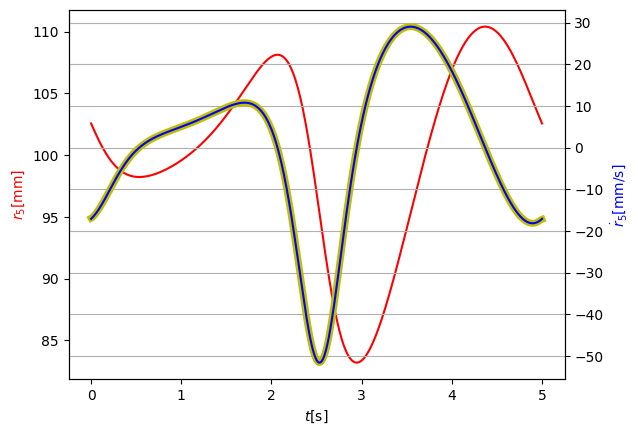

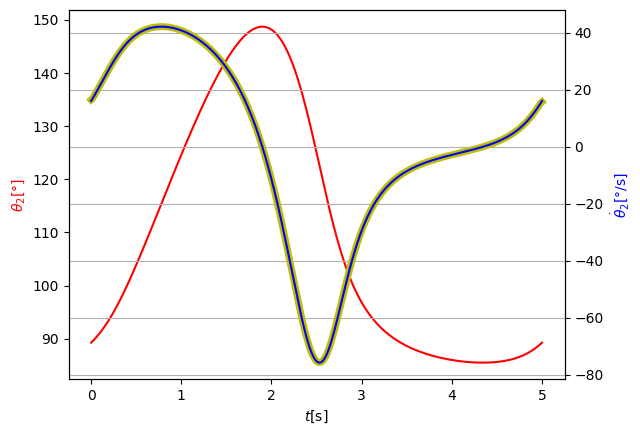

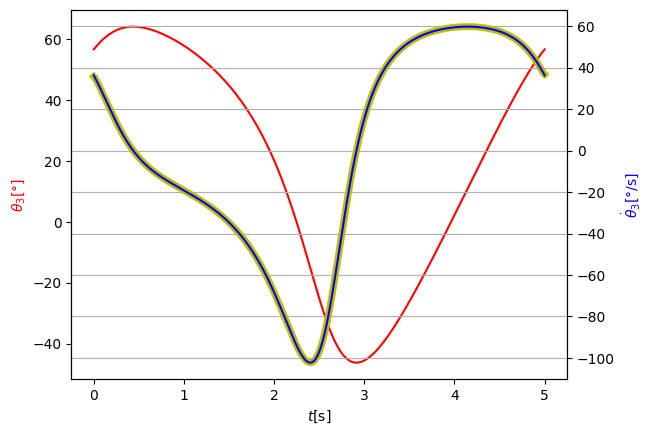

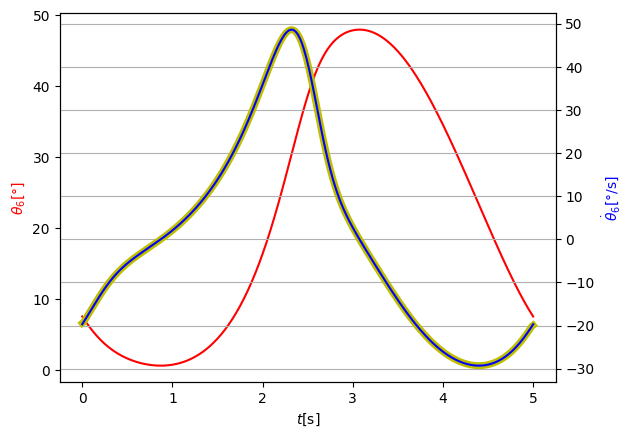

In [ ]:
fig, ax1 = plt.subplots() # reemplaza a plt.figure()
plt.xlabel(r"$t$[s]")
ax1.plot(df.index,df['r5'],'r')
ax1.set_ylabel(r"$r_5$[mm]",color = 'r')
ax2 = ax1.twinx() # Esto hace la magia: compartir gráfica pero ejes y diferentes
ax2.plot(df.index,df['r5p_num'],'y',linewidth=5)
ax2.plot(df.index,df['r5p'],'b')
ax2.set_ylabel(r"$\dot r_5$[mm/s]",color = 'b')
plt.grid()


fig, ax1 = plt.subplots() # reemplaza a plt.figure()
plt.xlabel(r"$t$[s]")
ax1.plot(df.index,np.degrees(df['th2']),'r')
ax1.set_ylabel(r"$\theta_2$[°]",color = 'r')
ax2 = ax1.twinx() # Esto hace la magia: compartir gráfica pero ejes y diferentes
ax2.plot(df.index,np.degrees(df['th2p_num']),'y',linewidth=5)
ax2.plot(df.index,np.degrees(df['th2p']),'b')
ax2.set_ylabel(r"$\dot \theta_2$[°/s]",color = 'b')
plt.grid()

fig, ax1 = plt.subplots() # reemplaza a plt.figure()
plt.xlabel(r"$t$[s]")
ax1.plot(df.index,np.degrees(df['th3']),'r')
ax1.set_ylabel(r"$\theta_3$[°]",color = 'r')
ax2 = ax1.twinx() # Esto hace la magia: compartir gráfica pero ejes y diferentes
ax2.plot(df.index,np.degrees(df['th3p_num']),'y',linewidth=5)
ax2.plot(df.index,np.degrees(df['th3p']),'b')
ax2.set_ylabel(r"$\dot \theta_3$[°/s]",color = 'b')
plt.grid()

fig, ax1 = plt.subplots() # reemplaza a plt.figure()
plt.xlabel(r"$t$[s]")
ax1.plot(df.index,np.degrees(df['th6']),'r')
ax1.set_ylabel(r"$\theta_6$[°]",color = 'r')
ax2 = ax1.twinx() # Esto hace la magia: compartir gráfica pero ejes y diferentes
ax2.plot(df.index,np.degrees(df['th6p_num']),'y',linewidth=5)
ax2.plot(df.index,np.degrees(df['th6p']),'b')
ax2.set_ylabel(r"$\dot \theta_6$[°/s]",color = 'b')
plt.grid()

# Análisis de aceleración

### Aceleración de las barras de entrada


**Nota:** En este caso, como la velocidad de la barra de entrada $\dot \theta_1$ es constante, $\ddot \theta_1 = 0$. De Todas formas vale la pena verificarlo:

In [ ]:
df['th1pp'] = np.gradient(df['th1p'],df.index)
df['th1pp']

,th1pp
t,
0.000000,3.836931e-13
0.013889,1.918465e-13
0.027778,0.000000e+00
0.041667,0.000000e+00
0.055556,-1.421085e-14
...,...
4.944444,-1.030287e-12
4.958333,1.023182e-12
4.972222,1.030287e-12


Si se observan valores diferentes de cero, corresponden a error numérico, por lo que, en este caso, podemos asumir lo siguiente:

In [ ]:
th1pp = 0

### Derivando las ecuaciones por segunda vez

$r_{1} \sin{\left(\theta_{1} \right)} \ddot{\theta}_{1} + r_{1} \cos{\left(\theta_{1} \right)} \dot{\theta}_{1}^{2} + r_{2} \sin{\left(\theta_{2} \right)} \ddot{\theta}_{2} + r_{2} \cos{\left(\theta_{2} \right)} \dot{\theta}_{2}^{2} + r_{3} \sin{\left(\theta_{3} \right)} \ddot{\theta}_{3} + r_{3} \cos{\left(\theta_{3} \right)} \dot{\theta}_{3}^{2}=0$
$r_{1} \sin{\left(\theta_{1} \right)} \dot{\theta}_{1}^{2} - r_{1} \cos{\left(\theta_{1} \right)} \ddot{\theta}_{1} + r_{2} \sin{\left(\theta_{2} \right)} \dot{\theta}_{2}^{2} - r_{2} \cos{\left(\theta_{2} \right)} \ddot{\theta}_{2} + r_{3} \sin{\left(\theta_{3} \right)} \dot{\theta}_{3}^{2} - r_{3} \cos{\left(\theta_{3} \right)} \ddot{\theta}_{3}=0$
$- r_{3} \sin{\left(\theta_{3} \right)} \ddot{\theta}_{3} - r_{3} \cos{\left(\theta_{3} \right)} \dot{\theta}_{3}^{2} - r_{6} \sin{\left(\theta_{6} \right)} \ddot{\theta}_{6} - r_{6} \cos{\left(\theta_{6} \right)} \dot{\theta}_{6}^{2} + r_{8} \sin{\left(\beta - \theta_{2} \right)} \ddot{\theta}_{2} - r_{8} \cos{\left(\beta - \theta_{2} \right)} \dot{\theta}_{2}^{2} + \cos{\left(\theta_{5} \right)} \ddot{r}_{5}=0$
$- r_{3} \sin{\left(\theta_{3} \right)} \dot{\theta}_{3}^{2} + r_{3} \cos{\left(\theta_{3} \right)} \ddot{\theta}_{3} - r_{6} \sin{\left(\theta_{6} \right)} \dot{\theta}_{6}^{2} + r_{6} \cos{\left(\theta_{6} \right)} \ddot{\theta}_{6} + r_{8} \sin{\left(\beta - \theta_{2} \right)} \dot{\theta}_{2}^{2} + r_{8} \cos{\left(\beta - \theta_{2} \right)} \ddot{\theta}_{2} + \sin{\left(\theta_{5} \right)} \ddot{r}_{5}=0$


Luego llevamos este sistema a la forma $Ax = b$

Notaremos que la matriz A se conserva, solo cambia el vector b:

$b = \left[\begin{smallmatrix}- r_{1} \sin{\left(\theta_{1} \right)} \ddot{\theta}_{1} - r_{1} \cos{\left(\theta_{1} \right)} \dot{\theta}_{1}^{2} - r_{2} \cos{\left(\theta_{2} \right)} \dot{\theta}_{2}^{2} - r_{3} \cos{\left(\theta_{3} \right)} \dot{\theta}_{3}^{2}\\- r_{1} \sin{\left(\theta_{1} \right)} \dot{\theta}_{1}^{2} + r_{1} \cos{\left(\theta_{1} \right)} \ddot{\theta}_{1} - r_{2} \sin{\left(\theta_{2} \right)} \dot{\theta}_{2}^{2} - r_{3} \sin{\left(\theta_{3} \right)} \dot{\theta}_{3}^{2}\\r_{3} \cos{\left(\theta_{3} \right)} \dot{\theta}_{3}^{2} + r_{6} \cos{\left(\theta_{6} \right)} \dot{\theta}_{6}^{2} + r_{8} \cos{\left(\beta - \theta_{2} \right)} \dot{\theta}_{2}^{2}\\r_{3} \sin{\left(\theta_{3} \right)} \dot{\theta}_{3}^{2} + r_{6} \sin{\left(\theta_{6} \right)} \dot{\theta}_{6}^{2} - r_{8} \sin{\left(\beta - \theta_{2} \right)} \dot{\theta}_{2}^{2}\end{smallmatrix}\right]$

Ahora sí, a resolver el sistema lineal para todas las posiciones analizadas:

In [ ]:
th2ppv = np.zeros(0)
th3ppv = np.zeros(0)
th6ppv = np.zeros(0)
r5ppv = np.zeros(0)
## Extraigo los valores de las variables que requieren las matrices, es decir:
## variables de entrada, variables de posición ,variables de velocidad
for th2,th2p,th3,th3p,th6,th6p,r5,r5p,th1 in zip(df['th2'],df['th2p'],
                                                 df['th3'],df['th3p'],
                                                 df['th6'],df['th6p'],
                                                 df['r5'],df['r5p'],
                                                 df['th1']):
  # evaluar con valores numéricos específicos
  am = [[r2*np.sin(th2),r3*np.sin(th3),0,0],
          [-r2*np.cos(th2),-r3*np.cos(th3),0,0],
          [r8*np.sin(beta-th2),-r3*np.sin(th3),-r6*np.sin(th6),np.cos(th5)],
          [r8*np.cos(beta-th2),r3*np.cos(th3),r6*np.cos(th6),np.sin(th5)]]
  bv = [-r1*np.sin(th1)*th1pp-r1*np.cos(th1)*th1p**2-r2*np.cos(th2)*th2p**2-r3*np.cos(th3)*th3p**2,
        r1*np.cos(th1)*th1pp-r1*np.sin(th1)*th1p**2-r2*np.sin(th2)*th2p**2-r3*np.sin(th3)*th3p**2,
        r3*np.cos(th3)*th3p**2 + r6*np.cos(th6)*th6p**2 + r8*np.cos(beta-th2)*th2p**2,
        r3*np.sin(th3)*th3p**2 + r6*np.sin(th6)*th6p**2 - r8*np.sin(beta-th2)*th2p**2]
  [th2pp,th3pp,th6pp,r5pp] = np.linalg.solve(am,bv) # el resultado de solve es el vector x

  th2ppv = np.append(th2ppv,th2pp)
  th3ppv = np.append(th3ppv,th3pp)
  th6ppv = np.append(th6ppv,th6pp)
  r5ppv = np.append(r5ppv,r5pp)

Recordemos agregar al DataFrame

In [ ]:
df['th2pp'] = th2ppv
df['th3pp'] = th3ppv
df['th6pp'] = th6ppv
df['r5pp'] = r5ppv
df

,th1,th2,th3,th6,r5,Dx,Dy,Cx,Cy,Ex,...,r5p,r5p_num,th2p_num,th3p_num,th6p_num,th1pp,th2pp,th3pp,th6pp,r5pp
t,,,,,,,,,,,,,,,,,,,,,
0.000000,-1.919862,1.558316,0.989760,0.132269,102.566330,-11.842889,-39.809832,-12.498098,-92.305743,-22.796128,...,-17.086427,-16.941606,0.287337,0.622847,-0.339713,3.836931e-13,0.896994,-1.415947,0.571890,20.029533
0.013889,-1.902409,1.562307,0.998411,0.127550,102.331029,-11.599965,-39.967849,-12.045668,-92.465957,-22.549073,...,-16.791110,-16.785542,0.293713,0.612758,-0.335684,1.918465e-13,0.918208,-1.453071,0.580218,22.481345
0.027778,-1.884956,1.566475,1.006781,0.122944,102.100064,-11.363617,-40.118741,-11.590511,-92.618251,-22.308225,...,-16.462396,-16.457074,0.306599,0.592339,-0.327577,0.000000e+00,0.937796,-1.487771,0.587376,24.835760
0.041667,-1.867502,1.570823,1.014865,0.118451,101.873888,-11.134181,-40.262577,-11.132766,-92.762577,-22.073891,...,-16.101758,-16.096721,0.319745,0.571457,-0.319380,0.000000e+00,0.955518,-1.519677,0.593282,27.075623
0.055556,-1.850049,1.575356,1.022655,0.114072,101.652933,-10.911971,-40.399439,-10.672571,-92.898893,-21.846355,...,-15.710903,-15.706188,0.333122,0.550154,-0.311109,-1.421085e-14,0.971144,-1.548434,0.597864,29.184307
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4.944444,4.293510,1.544038,0.952504,0.152225,103.541215,-12.873165,-39.105490,-14.277802,-91.586696,-23.839753,...,-17.912645,-17.906440,0.233892,0.706836,-0.374314,-1.030287e-12,0.800691,-1.250612,0.528734,9.590392
4.958333,4.310963,1.547364,0.962200,0.147078,103.293440,-12.607559,-39.292492,-13.837650,-91.778080,-23.571237,...,-17.760868,-17.754715,0.245188,0.689168,-0.366887,1.023182e-12,0.826013,-1.293749,0.540805,12.261744
4.972222,4.328417,1.550849,0.971647,0.142034,103.048029,-12.347056,-39.472197,-13.394225,-91.961752,-23.307555,...,-17.572181,-17.566117,0.256831,0.670907,-0.359299,1.030287e-12,0.850657,-1.335918,0.552087,14.902818


### Verificación numérica

voy a calcular $\ddot{\theta_2},\ddot{\theta_3},\ddot{\theta_6},\ddot{r_5}$ de forma numérica, dado que tengo un vector de tiempo en el índice de mi DataFrame

In [ ]:
df['r5pp_num'] = np.gradient(df['r5p'],df.index)
df['th2pp_num'] = np.gradient(df['th2p'],df.index)
df['th3pp_num'] = np.gradient(df['th3p'],df.index)
df['th6pp_num'] = np.gradient(df['th6p'],df.index)

Podemos revisar parte de los datos para cada variable

In [ ]:
df[['r5pp','r5pp_num']]

,r5pp,r5pp_num
t,,
0.000000,20.029533,21.262834
0.013889,22.481345,22.465111
0.027778,24.835760,24.816665
0.041667,27.075623,27.053755
0.055556,29.184307,29.159817
...,...,...
4.944444,9.590392,9.587861
4.958333,12.261744,12.256703
4.972222,14.902818,14.895113


verifiquemos con la gráfica, me debe dar CASI igual a la obtenida analíticamente

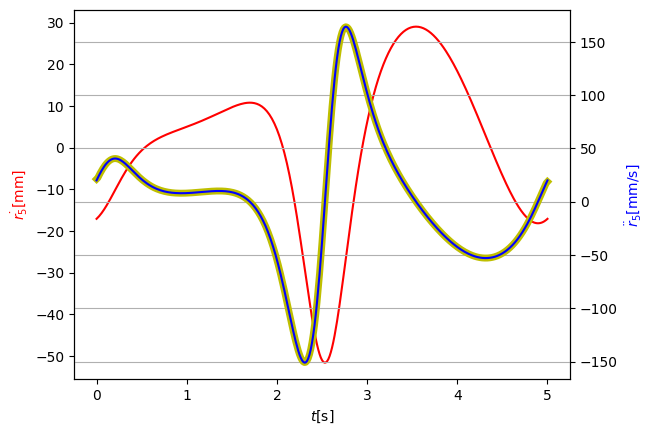

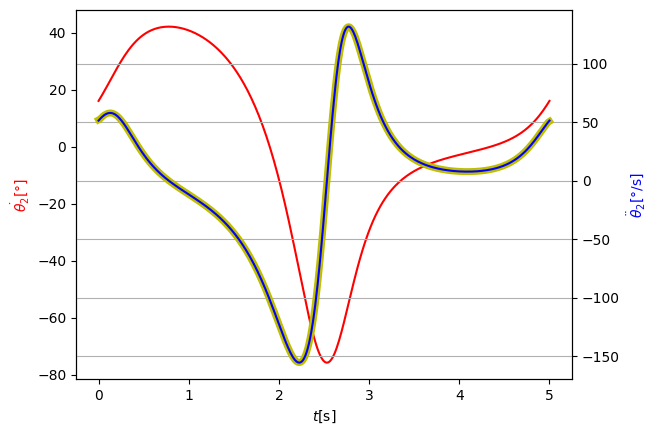

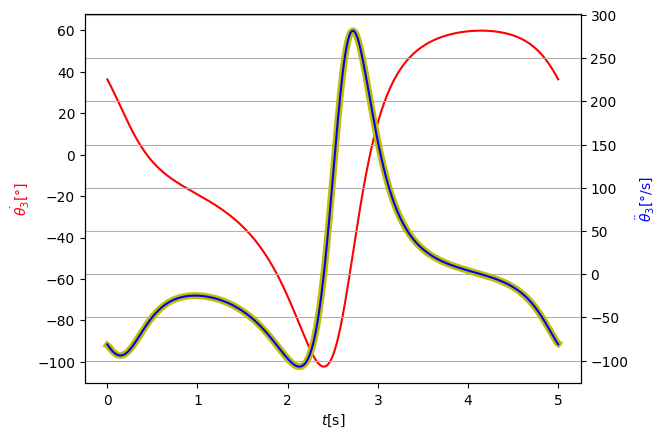

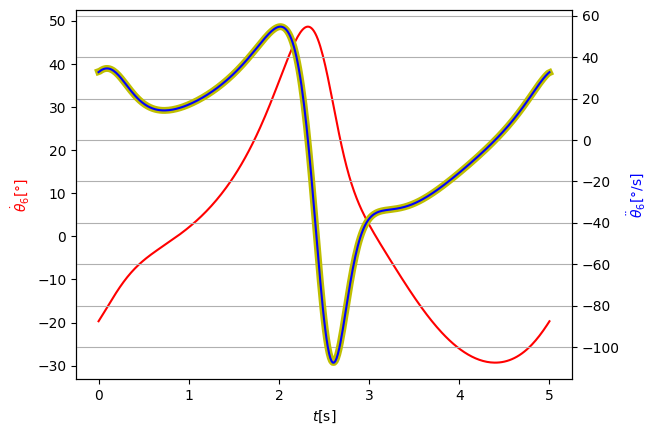

In [ ]:
fig, ax1 = plt.subplots() # reemplaza a plt.figure()
plt.xlabel(r"$t$[s]")
ax1.plot(df.index,df['r5p'],'r')
ax1.set_ylabel(r"$\dot{r_5}$[mm]",color = 'r')
ax2 = ax1.twinx() # Esto hace la magia: compartir gráfica pero ejes y diferentes
ax2.plot(df.index,df['r5pp_num'],'y',linewidth=5)
ax2.plot(df.index,df['r5pp'],'b')
ax2.set_ylabel(r"$\ddot r_5$[mm/s]",color = 'b')
plt.grid()


fig, ax1 = plt.subplots() # reemplaza a plt.figure()
plt.xlabel(r"$t$[s]")
ax1.plot(df.index,np.degrees(df['th2p']),'r')
ax1.set_ylabel(r"$\dot{\theta_2}$[°]",color = 'r')
ax2 = ax1.twinx() # Esto hace la magia: compartir gráfica pero ejes y diferentes
ax2.plot(df.index,np.degrees(df['th2pp_num']),'y',linewidth=5)
ax2.plot(df.index,np.degrees(df['th2pp']),'b')
ax2.set_ylabel(r"$\ddot \theta_2$[°/s]",color = 'b')
plt.grid()

fig, ax1 = plt.subplots() # reemplaza a plt.figure()
plt.xlabel(r"$t$[s]")
ax1.plot(df.index,np.degrees(df['th3p']),'r')
ax1.set_ylabel(r"$\dot{\theta_3}$[°]",color = 'r')
ax2 = ax1.twinx() # Esto hace la magia: compartir gráfica pero ejes y diferentes
ax2.plot(df.index,np.degrees(df['th3pp_num']),'y',linewidth=5)
ax2.plot(df.index,np.degrees(df['th3pp']),'b')
ax2.set_ylabel(r"$\ddot \theta_3$[°/s]",color = 'b')
plt.grid()

fig, ax1 = plt.subplots() # reemplaza a plt.figure()
plt.xlabel(r"$t$[s]")
ax1.plot(df.index,np.degrees(df['th6p']),'r')
ax1.set_ylabel(r"$\dot \theta_6$[°]",color = 'r')
ax2 = ax1.twinx() # Esto hace la magia: compartir gráfica pero ejes y diferentes
ax2.plot(df.index,np.degrees(df['th6pp_num']),'y',linewidth=5)
ax2.plot(df.index,np.degrees(df['th6pp']),'b')
ax2.set_ylabel(r"$\ddot \theta_6$[°/s]",color = 'b')
plt.grid()

## Velocidad y aceleración de cualquier punto del mecanismo

Ya tenemos todo para calcular la velocidad y aceleración lineal instantánea de cualquier punto del mecanismo.

El problema para resolver estas ecuaciones era hallar $\dot \theta$ y $\ddot \theta$, pero en las últimas secciones nos dedicamos a hallarlas, por lo que solo nos queda usar el modelo.

### Definición de puntos

Recordemos la definición de puntos que usamos para la animación

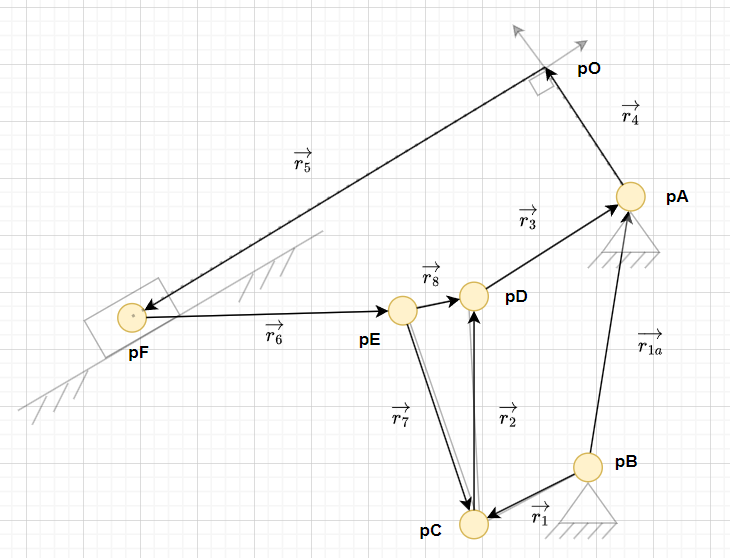

Si nos proponemos a hallar la velocidad del punto $pF$, una forma requiere lo siguiente:
- debo conocer la velocidad del punto $pE$, pero para esto
- debo conocer la velocidad del punto $pD$, pero para esto
- debo conocer la velocidad del punto $pC$, pero para esto
- debo conocer la velocidad del punto $pB$

pero la velocidad del punto $pB$ es CERO, ya que es un punto fijo, por lo que puedo empezar por aquí, siguiendo ese orden: $\overrightarrow{VpC},\overrightarrow{VpE},\overrightarrow{VpF}$.

Empecemos a calcular usando herramientas numéricas.

### Velocidad de los puntos indicados para una posición dada

Como los cálculos vectoriales de velocidad requieren vectores de posición de las barras y de velocidades angulares, haremos otra función que calcule esto previo al cálculo de las velocidades vectoriales.




Recordemos que el análisis que realizamos nos permitió obtener muchas posiciones del mecanismo para un rango de movimiento dado. Esta función recibe como argumento el número entero `pos`, donde se le indica una posición del DataFrame para obtener los datos:

In [ ]:
def actualizarVectores(pos):
  # Saco la fila "pos" del DataFrame
  fila = df.iloc[pos]
  # fila es una fila del df, por lo que tiene las mismas columnas, funciona igual que df
  ## OJO: crear como array de numpy, para poder hacer operaciones vectoriales.
  w1v = np.array([0,0,th1p])
  r1v = np.array([r1*np.cos(fila["th1"]),r1*np.sin(fila["th1"]),0])
  w2v = np.array([0,0,fila["th2p"]])
  r2v = np.array([r2*np.cos(fila["th2"]),r2*np.sin(fila["th2"]),0])
  w8v = np.array([0,0,fila["th2p"]]) #misma velocidad angular de la barra
  r8v_ = -np.array([r8*np.cos(fila["th2"]-beta),r8*np.sin(fila["th2"]-beta),0])
  w6v = np.array([0,0,fila["th6p"]])
  r6v_ = -np.array([r6*np.cos(fila["th6"]),r6*np.sin(fila["th6"]),0])
  # También voy a calcular los vectores de aceleración angular aquí
  alpha2 = np.array([0,0,fila["th2pp"]])
  alpha6 = np.array([0,0,fila["th6pp"]])
  return w1v,r1v,w2v,r2v,w8v,r8v_,w6v,r6v_,alpha2,alpha6

Vamos a calcular la velocidad de todos los puntos para una posición específica por medio de una nueva función que definiremos, y que a su vez hace uso de la función anterior.

In [ ]:
def actualizarVel(pos):

  w1v,r1v,w2v,r2v,w8v,r8v_,w6v,r6v_,alpha2,alpha6 = actualizarVectores(pos)
  velC = np.cross(w1v,r1v)
  velD = velC + np.cross(w2v,r2v)
  velE = velD + np.cross(w8v,r8v_)
  velF = velE + np.cross(w6v,r6v_)
  return velC,velD,velE,velF


Ahora probamos la función agregando algunos parámetros

[ 32.47344578 -11.81936767   0.        ]
[ 17.71905307 -11.63521607   0.        ]
[ 18.00381922 -14.71371079   0.        ]
[14.94412574  8.28366416  0.        ]


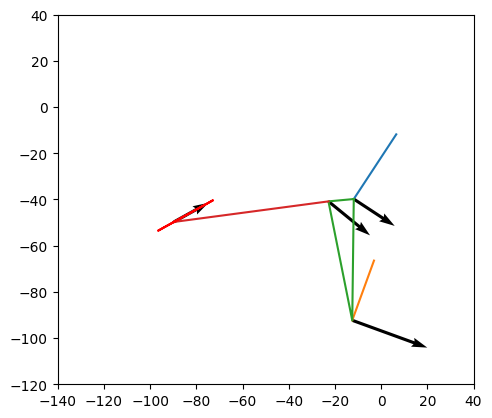

In [ ]:
### ESCALA DE LOS VECTORES
escala = 1

### Posición a analizar
pos = 0

### Origen de los vectores de velocidad (los puntos a analizar)
### los obtengo de la fila "pos" del dataframe
pCx,pCy,pDx,pDy,pEx,pEy,pFx,pFy = df[['Cx','Cy',
                                      'Dx','Dy',
                                      'Ex','Ey',
                                      'Fx','Fy']].iloc[pos]
velC,velD,velE,velF = actualizarVel(pos)

print(velC)
print(velD)
print(velE)
print(velF)

## PARA GRAFICAR LOS VECTORES COMO FLECHAS
hVD = ax_anim.quiver(pDx, pDy, velD[0], velD[1],scale_units='xy', scale=escala)
hVC = ax_anim.quiver(pCx, pCy, velC[0], velC[1],scale_units='xy', scale=escala)
hVE = ax_anim.quiver(pEx, pEy, velE[0], velE[1],scale_units='xy', scale=escala)
hVF = ax_anim.quiver(pFx, pFy, velF[0], velF[1],scale_units='xy', scale=escala)
fig_anim

## Aceleración del punto $pF$

Para encontrar la aceleración del punto $pF$ debemos encontrar la aceleración de los demás puntos que analizamos para su velocidad: $pE,pD,pC,pB$. Vamos a hacerlo todo en una sola celda, el procedimiento es similar al de velocidad.

La implementación en código se resume en estos pasos:

0. Definir el vector de aceleración angular $\overrightarrow{\alpha}$
1. Calcular la aceleración normal  $\overrightarrow{a_{B_n}}$
2. Calcular la aceleración tangencial $\overrightarrow{a_{B_t}}$
3. Calcular la aceleración de coriolis (si aplica, en la mayoría de los casos $\overrightarrow{V_{B-A}}$ es cero)
4. Evaluar la ecuación (16).


Vamos a poner todos los cálculos en una función, para poder agregarlo a la animación directamente

In [ ]:
def actualizarAcc(pos):
  w1v,r1v,w2v,r2v,w8v,r8v_,w6v,r6v_,alpha2,alpha6 = actualizarVectores(pos)
  # 0. Definir el vector de aceleración angular
  # la aceleración angular de la barra de entrada es 0 por lo que alpha1v = 0
  # 1. Calcular la aceleración normal
  aCn = np.cross(w1v,np.cross(w1v,r1v))
  # 2. Calcular la aceleración tangencial
  # al ser alpha1v = 0, esta también es 0
  # 3. Calcular la aceleración de coriolis
  # también es 0
  # 4. Evaluar la ecuación de aceleración
  # la aceleración del punto C es solo la componente normal, ya que la aceleración de B es 0
  aC = aCn
  ## Aceleración del punto D - se aplican los mismos pasos.
  aDn = np.cross(w2v,np.cross(w2v,r2v))
  aDt = np.cross(alpha2,r2v)
  aD = aC + aDn + aDt
  # Aceleración del punto E
  aEn = np.cross(w2v,np.cross(w2v,r8v_))
  aEt = np.cross(alpha2,r8v_)
  aE = aD + aEn + aEt
  # Aceleración del punto F
  aFn = np.cross(w6v,np.cross(w6v,r6v_))
  aFt = np.cross(alpha6,r6v_)
  aF = aE + aFn + aFt
  return aC,aD,aE,aF

aC,aD,aE,aF = actualizarAcc(pos) #ejemplo para la primera posición analizada
aC,aD,aE,aF

(array([14.85265545, 40.80733547, -0.        ]),
 array([-32.28761169,  37.24821437,   0.        ]),
 array([-30.51354771,  27.50326233,   0.        ]),
 array([-17.51822435,  -9.71051032,   0.        ]))

### Visualización de vectores de aceleración

Creamos los vectores y veámosolos para una sola posición.

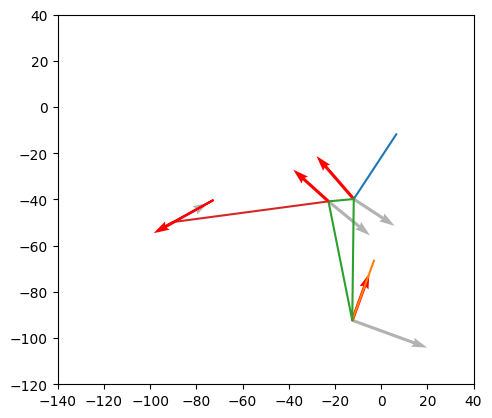

In [ ]:
escala_acel = escala*2 ## Los vectores de aceleración suelen ser muy grandes,
# se incrementa este número para que se vean más pequeños.

haE = ax_anim.quiver(pEx, pEy, aE[0], aE[1],scale_units='xy', scale=escala_acel, color='r')
# Graficar vector de aceleración del punto
haF = ax_anim.quiver(pFx, pFy, aF[0], aF[1],scale_units='xy', scale=escala_acel, color='r')
# Graficar vector de aceleración del punto
haC = ax_anim.quiver(pCx, pCy, aC[0], aC[1],scale_units='xy', scale=escala_acel, color='r')
# Graficar vector de aceleración del punto
haD = ax_anim.quiver(pDx, pDy, aD[0], aD[1],scale_units='xy', scale=escala_acel, color='r')
# # Grafiquemos también las componentes
# haDn = ax_anim.quiver(pDx, pDy, aDn[0], aDn[1],scale_units='xy', scale=25, color='g',alpha=0.5)
# haDt = ax_anim.quiver(pDx, pDy, aDt[0], aDt[1],scale_units='xy', scale=25, color='b',alpha=0.5)
# # Graficar vector de aceleración del punto
# haC = ax_anim.quiver(pDx, pDy, aC[0], aC[1],scale_units='xy', scale=25, color='k',alpha=0.5)

## Voy a poner las flechas de velocidad más claras para que no nos distraigan de observar la aceleración
hVC.set_alpha(0.3)
hVD.set_alpha(0.3)
hVE.set_alpha(0.3)
hVF.set_alpha(0.3)

fig_anim

### Agregar al DataFrame

siguiendo la convención de almacenar todo en el DataFrame, creemos un ciclo que calcula los vectores de posición, velocidad angular y aceleración angular para cada posición del mecanismo usando un ciclo `for`

In [ ]:
w1v_list = []
r1v_list = []
w2v_list = []
r2v_list = []
w8v_list = []
r8v_list = []
w6v_list = []
r6v_list = []
alpha2_list = []
alpha6_list = []

velC_list = []
velD_list = []
velE_list = []
velF_list = []
aC_list = []
aD_list = []
aE_list = []
aF_list = []

numpos = len(df)
for i in range(numpos):
    w1v,r1v,w2v,r2v,w8v,r8v_,w6v,r6v_,alpha2,alpha6 = actualizarVectores(i)
    velC,velD,velE,velF = actualizarVel(i)
    aC,aD,aE,aF = actualizarAcc(i)

    w1v_list.append(w1v)
    r1v_list.append(r1v)
    w2v_list.append(w2v)
    r2v_list.append(r2v)
    w8v_list.append(w8v)
    r8v_list.append(r8v_)
    w6v_list.append(w6v)
    r6v_list.append(r6v_)
    alpha2_list.append(alpha2)
    alpha6_list.append(alpha6)

    velC_list.append(velC)
    velD_list.append(velD)
    velE_list.append(velE)
    velF_list.append(velF)
    aC_list.append(aC)
    aD_list.append(aD)
    aE_list.append(aE)
    aF_list.append(aF)

df['w1v'] = w1v_list
df['r1v'] = r1v_list
df['w2v'] = w2v_list
df['r2v'] = r2v_list
df['w8v'] = w8v_list
df['r8v'] = r8v_list
df['w6v'] = w6v_list
df['r6v'] = r6v_list
df['alpha2'] = alpha2_list
df['alpha6'] = alpha6_list

df['velC'] = velC_list
df['velD'] = velD_list
df['velE'] = velE_list
df['velF'] = velF_list
df['aC'] = aC_list
df['aD'] = aD_list
df['aE'] = aE_list
df['aF'] = aF_list

df

,th1,th2,th3,th6,r5,Dx,Dy,Cx,Cy,Ex,...,alpha2,alpha6,velC,velD,velE,velF,aC,aD,aE,aF
t,,,,,,,,,,,,,,,,,,,,,
0.000000,-1.919862,1.558316,0.989760,0.132269,102.566330,-11.842889,-39.809832,-12.498098,-92.305743,-22.796128,...,"[0.0, 0.0, 0.8969938557367196]","[0.0, 0.0, 0.5718901500294709]","[32.473445775029084, -11.819367666168157, 0.0]","[17.719053065352604, -11.635216074453455, 0.0]","[18.00381922287623, -14.713710789515945, 0.0]","[14.94412573668324, 8.283664161891798, 0.0]","[14.852655452044269, 40.80733547343121, -0.0]","[-32.287611688935996, 37.2482143720834, 0.0]","[-30.51354770790475, 27.503262333512396, 0.0]","[-17.518224347272035, -9.710510321073166, 0.0]"
0.013889,-1.902409,1.562307,0.998411,0.127550,102.331029,-11.599965,-39.967849,-12.045668,-92.465957,-22.549073,...,"[0.0, 0.0, 0.9182084278335235]","[0.0, 0.0, 0.5802183370214353]","[32.67477632029053, -11.25082774513931, 0.0]","[17.257906094477, -11.119940053202285, 0.0]","[17.56828022502921, -14.335312650462049, 0.0]","[14.68583554899587, 8.140491572955254, 0.0]","[14.138207116373568, 41.060334898205845, -0.0]","[-34.104435302283356, 36.942184688719536, 0.0]","[-32.18973971932775, 26.97976749078412, 0.0]","[-19.66262749986801, -10.89917239852096, 0.0]"
0.027778,-1.884956,1.566475,1.006781,0.122944,102.100064,-11.363617,-40.118741,-11.590511,-92.618251,-22.308225,...,"[0.0, 0.0, 0.9377964799561456]","[0.0, 0.0, 0.5873763599726829]","[32.866153812157165, -10.678860712990078, 0.0]","[16.77210364719679, -10.609304904708315, 0.0]","[17.110088925850228, -13.964442317956973, 0.0]","[14.39833603709704, 7.981127991221474, 0.0]","[13.419452145855335, 41.300826947210105, -0.0]","[-35.83572601717931, 36.57987663082962, 0.0]","[-33.77324559970561, 26.419673315051348, 0.0]","[-21.72184524640431, -12.04061543433821, 0.0]"
0.041667,-1.867502,1.570823,1.014865,0.118451,101.873888,-11.134181,-40.262577,-11.132766,-92.762577,-22.073891,...,"[0.0, 0.0, 0.9555184216086147]","[0.0, 0.0, 0.5932822926804694]","[33.04751995519103, -10.103640796419224, 0.0]","[16.262927910816316, -10.104093223423698, 0.0]","[16.63062492370936, -13.601589738014324, 0.0]","[14.082914868025282, 7.806287182185189, 0.0]","[12.696609480216322, 41.52873836423615, -0.0]","[-37.467962992150945, 36.16124274693858, 0.0]","[-35.250841212287675, 25.825703586977745, 0.0]","[-23.68087387364194, -13.126522734471113, 0.0]"
0.055556,-1.850049,1.575356,1.022655,0.114072,101.652933,-10.911971,-40.399439,-10.672571,-92.898893,-21.846355,...,"[0.0, 0.0, 0.9711439759373222]","[0.0, 0.0, 0.5978643408211353]","[33.218819503508016, -9.525343212985614, 0.0]","[15.731846141224207, -9.605084426444575, 0.0]","[16.131448030569178, -13.247203842180221, 0.0]","[13.741065274546036, 7.616796858284195, 0.0]","[11.969899304334819, 41.743999725258504, -0.0]","[-38.988068456275435, 35.686795782921486, 0.0]","[-36.6098516929827, 25.20103751477542, 0.0]","[-25.525170426813887, -14.148833007457476, 0.0]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4.944444,4.293510,1.544038,0.952504,0.152225,103.541215,-12.873165,-39.105490,-14.277802,-91.586696,-23.839753,...,"[0.0, 0.0, 0.8006911141143177]","[0.0, 0.0, 0.5287339659353597]","[31.569864682953273, -14.055809348160475, 0.0]","[19.29803929888274, -13.727359297561929, 0.0]","[19.498365910355858, -16.291706833106296, 0.0]","[15.666752533427646, 8.68422273614954, 0.0]","[17.663050955375898, 39.671861985116, -0.0]","[-24.43498682754211, 37.926987186117195, 0.0]","[-23.149399146181363, 29.192980639374163, 0.0]","[-8.38794581312608, -4.649514287311138, 0.0]"
4.958333,4.310963,1.547364,0.962200,0.147078,103.293440,-12.607559,-39.292492,-13.837650,-91.778080,-23.571237,...,"[0.0, 0.0, 0.826013465983791]","[0.0, 0.0, 0.5408049751195118]","[31.81036413719905, -13.50269847069897, 0.0]","[18.94457314831511, -13.201166245113212, 0.0]","[19.163517349518038, -15.888692434413663, 0.0]","[15.534005319725374, 8.610639754039234, 0.0]","[16.967991327674433, 39.97408251257636,

Como resultado, vamos a ver al final del DataFrame, columnas donde cada fila es un vector de 3 posiciones, así:

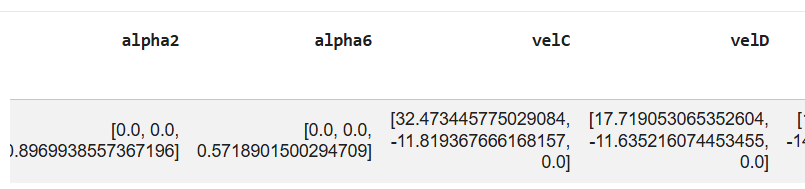

## Animación de los vectores de velocidad y aceleración

Debemos modificar la función de animación y regenerarla



In [ ]:
escala = 1
escala_acel = escala * 2 # entre más grande la escala, más pequeñas las flechas

def animar(pos):
    #tomar el punto actual de las listas de puntos
    #El módulo de animación tomará una posición a la vez y graficará con esto
    pCx,pCy,pDx,pDy,pEx,pEy,pFx,pFy = df[['Cx','Cy',
                                      'Dx','Dy',
                                      'Ex','Ey',
                                      'Fx','Fy']].iloc[pos]
    velC,velD,velE,velF = df[['velC','velD','velE','velF']].iloc[pos]
    aC,aD,aE,aF = df[['aC','aD','aE','aF']].iloc[pos]

    #modificar la posición de las barras previamente creadas en la gráfica (fig)
    hr3[0].set_xdata([pDx,pAx]) #barra 3
    hr3[0].set_ydata([pDy,pAy]) #barra 3
    hr1[0].set_xdata([pBx,pCx]) #barra 1
    hr1[0].set_ydata([pBy,pCy]) #barra 1
    hDCED[0].set_xdata([pDx,pCx,pEx,pDx]) #barra ternaria
    hDCED[0].set_ydata([pDy,pCy,pEy,pDy])
    hr6[0].set_xdata([pEx,pFx]) #acopladora
    hr6[0].set_ydata([pEy,pFy])
    #modificación de vectores de velocidad
    #cambiar la escala de los vectores de velocidad con la variable "escala"
    #velocidad
    hVC.set_UVC(velC[0],velC[1],escala)
    hVC.set_offsets([pCx,pCy])
    hVD.set_UVC(velD[0],velD[1],escala)
    hVD.set_offsets([pDx,pDy])
    hVE.set_UVC(velE[0],velE[1],escala)
    hVE.set_offsets([pEx,pEy])
    hVF.set_UVC(velF[0],velF[1],escala)
    hVF.set_offsets([pFx,pFy])
    #aceleración
    #cambiar la escala de los vectores de aceleración con la variable "escala_acel"
    haC.set_UVC(aC[0],aC[1],escala_acel)
    haC.set_offsets([pCx,pCy])
    haD.set_UVC(aD[0],aD[1],escala_acel)
    haD.set_offsets([pDx,pDy])
    haE.set_UVC(aE[0],aE[1],escala_acel)
    haE.set_offsets([pEx,pEy])
    haF.set_UVC(aF[0],aF[1],escala_acel)
    haF.set_offsets([pFx,pFy])
    # Retornar siempre las barras que se están moviendo.
    return hr3[0],hr1[0],hDCED[0],hr6[0]

animacion = generar_animacion(fig_anim,t_sim)

Número de Cuadros: 91
Incremento de la variable de entrada: 4


### Presentación de animación

In [ ]:
#En Jupyter se pueden mostrar las animaciones directamente en el cuaderno
from IPython.display import HTML

# Comentar para reducir tamaño del cuaderno, generar animación en formato gif o mp4, requiere instalar ffmpeg
#animacion.save('animation.mp4', writer='ffmpeg', fps=15)
HTML(animacion.to_jshtml())

## Sympy: matemáticas simbólicas (Opcional)

Utilizaremos este módulo para realizar las derivadas simbólicas. Importamos el módulo básico y uno adicional para simplificar la notación de Newton

In [ ]:
import sympy as sym
from sympy.physics.mechanics import dynamicsymbols, init_vprinting, vlatex

sym.init_printing(use_unicode=False, wrap_line=True)
init_vprinting()

#### Definición de la variable independiente (tiempo)

In [ ]:
t = sym.Symbol('t') # defino t como la variable independiente, en este caso el tiempo


#### Definición de parámetros (cosas que no cambian en el tiempo)

Algunas sugerencias:

- es útil que la nomenclatura de las variables **simbólicas** se parezca a la de las variables **numéricas**. Yo lo que hago es ponerle una 's' al final del nombre de la variable original. Esto es opcional.
- para la definición del símbolo, usar notación matemática, la misma que se usa en las ecuaciones en las celdas de texto. Por ejemplo, la cantidad $r_{1a}$ se define con el código `r_{1a}` y $\theta_{1a}$ con el código `\theta_{1a}`

In [ ]:
# Parámetros
r1s = sym.Symbol('r_1') #uso notación matemática para que queden las ecuaciones bonitas
r1as = sym.Symbol('r_1a')
r2s = sym.Symbol('r_2')
r3s = sym.Symbol('r_3')
r4s = sym.Symbol('r_4')
r6s = sym.Symbol('r_6')
r8s = sym.Symbol('r_8')

th1as = sym.Symbol('theta_1a')
th4s = sym.Symbol('theta_4')
th5s = sym.Symbol('theta_5')

betas = sym.Symbol('beta')

r1as,th1as,betas

### Definición de variables (cosas que cambian en el tiempo)

Las variables dependen del tiempo, esto se debe hacer explícito en sympy, usando la función `dynamicsymbols()`, con los siguientes parámetros:

In [ ]:
# Variables definidas como símbolos dinámicos para que dependan de t

th1s, th2s, th3s, th6s, r5s = dynamicsymbols('theta_1 theta_2 theta_3 theta_6 r_5')
th1s,th2s,th3s,th6s,r5s

### Definición de variables derivadas

In [ ]:
# Primera derivada de las variables con respecto al tiempo
th1sp = sym.diff(th1s,t)
th2sp = sym.diff(th2s,t)
th3sp = sym.diff(th3s,t)
th6sp = sym.diff(th6s,t)
r5sp = sym.diff(r5s,t)
# Segunda derivada de las variables con respecto al tiempo
th1spp = sym.diff(th1s,t,t)
th2spp = sym.diff(th2s,t,t)
th3spp = sym.diff(th3s,t,t)
th6spp = sym.diff(th6s,t,t)
r5spp = sym.diff(r5s,t,t)


th1sp,th1spp,th2sp,th2spp,th3sp,th3spp,th6sp,th6spp,r5sp,r5spp

### Derivada del sistema de ecuaciones

Luego derivamos cada una de las expresiones de las ecuaciones (3), (4), (7) y (8) con respecto a t:

Partimos de las ecuaciones implementadas en la función:
```python
  x1 = -r1*np.cos(th1)+r1a*np.cos(th1a)-r3*np.cos(th3)-r2*np.cos(th2)
  y1 = -r1*np.sin(th1)+r1a*np.sin(th1a)-r3*np.sin(th3)-r2*np.sin(th2)
  x2 = r4*np.cos(th4) + r5*np.cos(th5) + r6*np.cos(th6) + r8*np.cos(th8) + r3*np.cos(th3)
  y2 = r4*np.sin(th4) + r5*np.sin(th5) + r6*np.sin(th6) + r8*np.sin(th8) + r3*np.sin(th3)
```
Las ecuaciones a derivar se implementarían así (notemos las semejanzas con las anteriores):

In [ ]:
eqx1 = -r1s*sym.cos(th1s)+r1as*sym.cos(th1as)-r3s*sym.cos(th3s)-r2s*sym.cos(th2s)
eqy1 = -r1s*sym.sin(th1s)+r1as*sym.sin(th1as)-r3s*sym.sin(th3s)-r2s*sym.sin(th2s)
eqx2 = r4s*sym.cos(th4s) + r5s*sym.cos(th5s) + r6s*sym.cos(th6s) + r8s*sym.cos(th2s-betas) + r3s*sym.cos(th3s)
eqy2 = r4s*sym.sin(th4s) + r5s*sym.sin(th5s) + r6s*sym.sin(th6s) + r8s*sym.sin(th2s-betas) + r3s*sym.sin(th3s)


In [ ]:
eqx1

In [ ]:
eqy1

In [ ]:
eqx2

In [ ]:
eqy2

Ahora las derivamos con respecto al tiempo

In [ ]:
eqx1p = sym.diff(eqx1,t)
eqx2p = sym.diff(eqx2,t)
eqy1p = sym.diff(eqy1,t)
eqy2p = sym.diff(eqy2,t)


In [ ]:
eqx1p


In [ ]:
eqy1p

In [ ]:
eqx2p

In [ ]:
eqy2p

#### Expresando el sistema de ecuaciones en forma matricial

Para hacer esto debemos usar la función "linear_eq_to_matrix", la cual requiere una lista de ecuaciones y el vector de incógnitas "x"

In [ ]:
eqns = [eqx1p,eqy1p,eqx2p,eqy2p]
x = [th2sp,th3sp,th6sp,r5sp]
As, bs = sym.linear_eq_to_matrix(eqns,x)
x

In [ ]:
As

In [ ]:
bs

### Solución analítica desde modelo simbólico con lambdify()

Esto lo que hace es crear funciones numéricas a partir de expresiones simbólicas. Cuando tenga las funciones numéricas, puedo obtener las matrices A y b para los correspondientes valores numéricos de variables y parámetros.

#### Crear funciones numéricas

In [ ]:
# Matriz A
# definir todos los términos simbólicos que tiene la matriz A
varA = [r2s, th2s,r3s,th3s,r8s,betas,r6s,th6s,th5s]
# crear función a partir de la expresión simbólica
a_func = sym.lambdify(varA, As, modules='numpy')

# Vector b
# definir todos los términos simbólicos que tiene el vector b
varb = [r1s, th1s, th1sp]
b_func = sym.lambdify(varb, bs, modules='numpy')


Podemos usar estas funciones para obtener la matriz $A$ y vector $b$ con valores numéricos, para hallar las soluciones al sistema lineal usando `np.linalg.solve()`.

### [Opcional] Derivando por segunda vez con Sympy

In [ ]:
eqx1pp = sym.diff(eqx1p,t)
eqx2pp = sym.diff(eqx2p,t)
eqy1pp = sym.diff(eqy1p,t)
eqy2pp = sym.diff(eqy2p,t)


In [ ]:
eqx1pp


In [ ]:
eqy1pp

In [ ]:
eqx2pp

In [ ]:
eqy2pp

#### Expresando el sistema de ecuaciones en forma matricial

Para hacer esto debemos usar la función "linear_eq_to_matrix", la cual requiere una lista de ecuaciones y el vector de incógnitas "x"

In [ ]:
eqns = [eqx1pp,eqy1pp,eqx2pp,eqy2pp]
x = [th2spp,th3spp,th6spp,r5spp]
As, b2s = sym.linear_eq_to_matrix(eqns,x)
x

In [ ]:
As

In [ ]:
b2s

### [Opcional] Solución analítica desde modelo simbólico con lambdify()

Es similar al análisis de velocidad, con la ventaja de que puedo reutilizar la función `a_func()`, ya que la matriz A no cambió. Vamos a crear la función numérica para el vector $b$

**Nota:** si no está usando sympy, puede crear el nuevo vector $b$ manualmente, como se hizo al principio del análisis de velocidad.

#### Crear funciones numéricas

In [ ]:
# Vector b
# definir todos los términos simbólicos que tiene el vector b
varb2 = [r1s, th1s, th1sp, th1spp, r2s, th2s, th2sp, r3s, th3s, th3sp, r6s, th6s, th6sp, r8s, betas]
b2_func = sym.lambdify(varb2, b2s, modules='numpy')


#### Evaluar las funciones para cada posición a analizar

A diferencia de ingresar las matrices a mano, con las funciones `a_func()` y `b_func()` generamos las matrices a partir del modelo simbólico, para luego poder resolver el sistema de ecuaciones.

OJO: cuidado con el orden de términos en el vector x; si espero los valores `[th2pp,th3pp,th6pp,r5pp]` es porque en el sistema simbólico están definidos en este orden.


In [ ]:
th2ppv = np.zeros(0)
th3ppv = np.zeros(0)
th6ppv = np.zeros(0)
r5ppv = np.zeros(0)
## Extraigo los valores de las variables que requieren las matrices, es decir:
## variables de entrada
## variables de posición
## variables de velocidad
for th2,th2p,th3,th3p,th6,th6p,r5,r5p,th1 in zip(df['th2'],df['th2p'],
                                                 df['th3'],df['th3p'],
                                                 df['th6'],df['th6p'],
                                                 df['r5'],df['r5p'],
                                                 df['th1']):
  # evaluar con valores numéricos específicos
  am = a_func(r2,th2,r3,th3,r8,beta,r6,th6,th5)
  bv = b2_func(r1, th1, th1p, th1pp, r2, th2, th2p, r3, th3, th3p, r6, th6, th6p, r8, beta).reshape(4) # reshape para que quede como vector de una dimensión y no saque warnings.

  [th2pp,th3pp,th6pp,r5pp] = np.linalg.solve(am,bv) # el resultado de solve es el vector x

  th2ppv = np.append(th2ppv,th2pp)
  th3ppv = np.append(th3ppv,th3pp)
  th6ppv = np.append(th6ppv,th6pp)
  r5ppv = np.append(r5ppv,r5pp)

## Análisis de rango de movimiento con variación de parámetros




Esto lo habíamos hecho para analizar el comportamiento de un mecanismo de 2 GDL. ¿Qué puedo analizar si solo tengo un GDL en este caso?

R/ puedo poner a variar un PARÁMETRO como si fuera una variable.

vamos a usar la función que resuelve el análisis de posición para las siguientes condiciones:

1. Para cada posición del **parámetro a variar** en un rango de valores desde el **valor original** hasta un valor **límite específico**:
   1. Llamar a la función que resuelve el análisis de posición, en este caso `atkinson_1gdl` con los siguientes argumentos:
   variable|valor inicial|incremento|límite
   -|-|-|-
   `th1`|`th1_ini`|1º|`th1_ini`+360º
   2. SI la función retorna listas vacías, detener el ciclo
   2. SINO almacenar los valores que retorna la función en una lista de DataFrames, de manera que quede una familia de DataFrames para cada variación del parámetro cambiado

A continuación haremos la prueba con un parámetro, por ejemplo, la longitud de la manivela $r_1$:

In [ ]:
r1_max = r1 + 20 #escogí un valor arbitrario
posiciones = 50
r1_rango = np.linspace(r1,r1_max,posiciones)

df_list = [] # aquí voy a guardar los dataframes

for r1_actual in r1_rango:
  th2v,th3v,th6v,r5v,th1v = atkinson_1gdl([th1_ini], # valores iniciales de th1
                                    [np.radians(1)],  # incrementos de th1
                                    [th1_ini + np.radians(360)]) # límites absolutos de th1

  if len(th1v) <= 1:
    print("No hay soluciones para",r1_actual)
    break
  else:
    df = pd.DataFrame({'th1':th1v,
                   'th2':th2v,
                   'th3': th3v,
                   'th6': th6v,
                   'r5': r5v
                   })
    df = calcularPuntos(df)
    df_list.append(df)


1
The solution converged.
último valor de th2: 1.5623066304148585
último valor de th3: 0.9984110972150803
último valor de th6: 0.12755032424075746
último valor de r5: 102.33102941490533
ciclos: 361
1
The solution converged.
último valor de th2: 1.5623066304148585
último valor de th3: 0.9984110972150803
último valor de th6: 0.12755032424075746
último valor de r5: 102.33102941490533
ciclos: 361
1
The solution converged.
último valor de th2: 1.5623066304148585
último valor de th3: 0.9984110972150803
último valor de th6: 0.12755032424075746
último valor de r5: 102.33102941490533
ciclos: 361
1
The solution converged.
último valor de th2: 1.5623066304148585
último valor de th3: 0.9984110972150803
último valor de th6: 0.12755032424075746
último valor de r5: 102.33102941490533
ciclos: 361
1
The solution converged.
último valor de th2: 1.5623066304148585
último valor de th3: 0.9984110972150803
último valor de th6: 0.12755032424075746
último valor de r5: 102.33102941490533
ciclos: 361
1
The solu

Ahora en el DataFrame tenemos el rango completo de movimiento del mecanismo para todos los puntos analizados. Sin embargo, sería de gran utilidad visualizar el área por donde el punto de interés se puede desplazar. Para esto, vamos a obtener los puntos que delimitan esta área.

### Área de movimiento de un punto de interés

Tomemos como punto de partida un punto cualquiera del mecanismo. En este caso tomaré el punto $E$



(-120.0, 40.0)

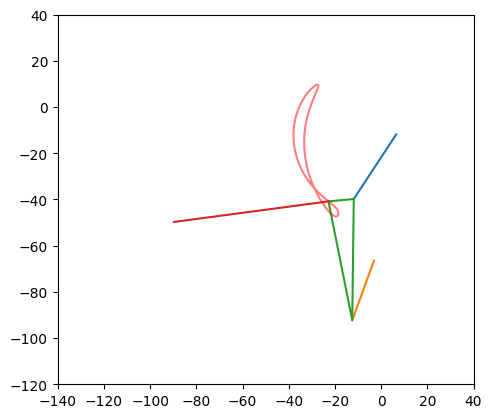

In [ ]:
df = df_list[0] # voy a tomar la primera posición del análisis
# Creo una FIGURA y un grupo de ejes (AXES), ya que los usaré después en la animación
fig3,ax3 = plt.subplots()

hr3 = plt.plot([pDx,pAx],[pDy,pAy])
hr1 = plt.plot([pBx,pCx],[pBy,pCy])
# para hacer una barra compuesta por varias aristas, delimito los puntos
hDCED = plt.plot([pDx,pCx,pEx,pDx],[pDy,pCy,pEy,pDy])
hr6 = plt.plot([pEx,pFx],[pEy,pFy])

ax3.plot(df["Ex"],df["Ey"],'r',alpha=0.5) #le agrego el argumento alpha para hacer la línea transparente

plt.axis("scaled")
plt.xlim([-140,40])
plt.ylim([-120,40])

Como tengo una **lista de DataFrames** con todas las ubicaciones del punto de interés $E$ para las variaciones que le hice al mecanismo, puedo graficar sobre esta misma figura, una línea sobre otra, usando los mismos parámetros, incluyendo la transparencia:

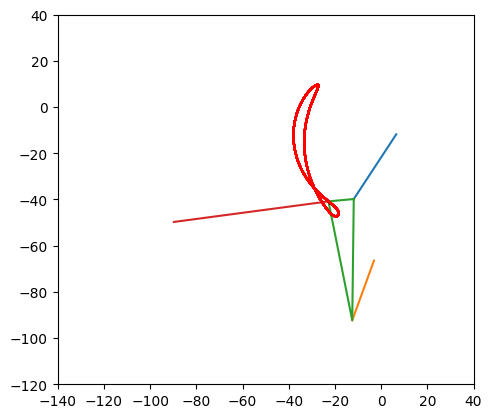

In [ ]:
for df in df_list:
  ax3.plot(df["Ex"],df["Ey"],'r',alpha=0.5) # alpha es transparencia, de 0 a 1, 1 es sólido, 0 es invisible
fig3

## TRABAJO FUTURO: Análisis de velocidad y aceleración de puntos de interés

Visualizar los vectores en una animación nos ayuda a entender visualmente el comportamiento de la velocidad y la aceleración de los puntos analizados, pero si queremos realizar un análisis, debemos obtener gráficas. Vamos a calcular la magnitud de los vectores de velocidad y aceleración, y generar gráficas similares a las de posición y las derivadas primera y segunda de las incógnitas con respecto al tiempo.

In [ ]:
# prompt: calculate the magnitude of vectors C,D,E,F, which x and y components are given by functions actualizarVectores, actualizarVel and actualizarAcc

def calcularMagnitudes(pos):
    velC, velD, velE, velF = actualizarVel(pos)
    aC, aD, aE, aF = actualizarAcc(pos)

    magnitud_velC = np.linalg.norm(velC[0:2])
    magnitud_velD = np.linalg.norm(velD[0:2])
    magnitud_velE = np.linalg.norm(velE[0:2])
    magnitud_velF = np.linalg.norm(velF[0:2])

    magnitud_aC = np.linalg.norm(aC[0:2])
    magnitud_aD = np.linalg.norm(aD[0:2])
    magnitud_aE = np.linalg.norm(aE[0:2])
    magnitud_aF = np.linalg.norm(aF[0:2])

    return magnitud_velC, magnitud_velD, magnitud_velE, magnitud_velF, magnitud_aC, magnitud_aD, magnitud_aE, magnitud_aF

m_velCv = np.array([])
m_velDv = np.array([])
m_velEv = np.array([])
m_velFv = np.array([])
m_aCv = np.array([])
m_aDv = np.array([])
m_aEv = np.array([])
m_aFv = np.array([])
for i in range(numpos):
    m_velC, m_velD, m_velE, m_velF, m_aC, m_aD, m_aE, m_aF = calcularMagnitudes(i)
    m_velCv = np.append(m_velCv, m_velC)
    m_velDv = np.append(m_velDv, m_velD)
    m_velEv = np.append(m_velEv, m_velE)
    m_velFv = np.append(m_velFv, m_velF)
    m_aCv = np.append(m_aCv, m_aC)
    m_aDv = np.append(m_aDv, m_aD)
    m_aEv = np.append(m_aEv, m_aE)
    m_aFv = np.append(m_aFv, m_aF)



KeyError: 'th2p'

In [ ]:
fig, ax1 = plt.subplots() # reemplaza a plt.figure()
plt.xlabel(r"$\theta_1$[°]")
ax1.plot(np.degrees(th1v),m_velCv,'r')
ax1.set_ylabel(r"$\|\overrightarrow{V_x}\|$[mm/s]",color = 'r')
ax1.plot(np.degrees(th1v),m_velDv,'g')
ax1.plot(np.degrees(th1v),m_velEv,'b')
ax1.plot(np.degrees(th1v),m_velFv,'m')
ax1.legend(['$C$','$D$','$E$','$F$'])
plt.grid()
## Ahora graficamos aceleración con los mismos colores pero líneas punteadas
# ax2 = ax1.twinx() # Esto hace la magia: compartir gráfica pero ejes y diferentes
fig, ax2 = plt.subplots() # reemplaza a plt.figure()
ax2.plot(np.degrees(th1v),m_aCv,'--r')
ax2.plot(np.degrees(th1v),m_aDv,'--g')
ax2.plot(np.degrees(th1v),m_aEv,'--b')
ax2.plot(np.degrees(th1v),m_aFv,'--m')
ax2.legend(['$C$','$D$','$E$','$F$'])
# ax2.plot(np.degrees(th1v),r5ppv_num,'y',linewidth=5)
# ax2.plot(np.degrees(th1v),r5ppv,'b')
# ax2.set_ylabel(r"$\ddot r_5$[mm/s^2]",color = 'b')
plt.grid()

